# Case Study 01: Smart Home Appliances Energy Consumption Forecasting
This notebook contains the code for the case study on forecasting energy consumption of smart home appliances. We will go through a complete Bayesian workflow and apply the Vangja package to build and evaluate forecasting models for different appliances in a smart home setting. 

Our goal is to utilize temperature data to improve the accuracy of our energy consumption forecasts when the training data for the appliances is limited. The datasets used in this case study are:
- Historical Hourly Weather Data (https://www.kaggle.com/datasets/selfishgene/historical-hourly-weather-data)
- Smart Home Dataset with weather Information (https://www.kaggle.com/datasets/taranvee/smart-home-dataset-with-weather-information)

## 1. Dataset

### 1.1 Data loading and preprocessing

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from vangja.datasets.loaders import load_kaggle_temperature, load_smart_home_readings
from vangja import FlatTrend, FourierSeasonality, UniformConstant
from vangja.time_series import TimeSeriesModel
from vangja.utils import (
    metrics,
    plot_prior_predictive,
    prior_predictive_coverage,
    plot_posterior_predictive,
)

def plot_both_dfs(df1, df2, title1="Series 1", title2="Series 2"):
    # Visualize both time series
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    # Temperature
    axes[0].plot(df1["ds"], df1["y"], "C0-", linewidth=0.5, alpha=0.7)
    axes[0].set_title(title1)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].grid(True, alpha=0.3)

    # Sales
    axes[1].plot(df2["ds"], df2["y"], "C1-", linewidth=0.5, alpha=0.7)
    axes[1].set_title(title2)
    axes[1].set_ylabel("Number of Sales")
    axes[1].set_xlabel("Date")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Our train data contains only 3 months of energy consumption readings, which is not enough to train a robust model. To overcome this challenge, we will leverage external data sources, specifically the daily maximum temperature readings for the city of Boston, to enhance our model's performance. We will use the temperature data to train a model that can capture yearly seasonality patters, which will be transferred to the energy consumption model to improve its predictions.

We start by loading the necessary datasets for our case study. First, we load the temperature data for Boston from the Kaggle dataset. We specify the city, the date range, and the frequency of the data we want to load. We use the date range from January 1, 2014, to March 31, 2016, to ensure we have at least two full years of data for our analysis and to ensure there is no data leakage i.e. the temperature data does not include future information.

In [6]:
temp_df = load_kaggle_temperature(
    city="Boston", start_date="2014-01-01", end_date="2016-03-31", freq="D"
)
temp_df

,ds,y,series
0,2014-01-01,-5.765000,Boston
1,2014-01-02,-6.108125,Boston
2,2014-01-03,-14.362083,Boston
3,2014-01-04,-12.607497,Boston
4,2014-01-05,-2.569375,Boston
...,...,...,...
816,2016-03-27,2.793056,Boston
817,2016-03-28,4.026540,Boston
818,2016-03-29,7.176683,Boston
819,2016-03-30,5.664472,Boston


We then load the energy consumption data from the smart home dataset. We specify the columns we are interested in, which include the energy consumption readings for Furnace 1, Furnace 2, Fridge, and Wine cellar. We also specify the frequency of the data as daily.

In [7]:
smart_home_df = load_smart_home_readings(
    column=["Furnace 1 [kW]", "Furnace 2 [kW]", "Fridge [kW]", "Wine cellar [kW]"],
    freq="D",
)
smart_home_df

,ds,y,series
0,2016-01-01,0.083106,Fridge [kW]
1,2016-01-02,0.051980,Fridge [kW]
2,2016-01-03,0.063992,Fridge [kW]
3,2016-01-04,0.049317,Fridge [kW]
4,2016-01-05,0.055650,Fridge [kW]
...,...,...,...
1399,2016-12-12,0.028141,Wine cellar [kW]
1400,2016-12-13,0.021090,Wine cellar [kW]
1401,2016-12-14,0.027129,Wine cellar [kW]
1402,2016-12-15,0.018033,Wine cellar [kW]


### 1.2 Data visualization
Let's plot the temperature and energy consumption data to visualize the patterns and relationships between them. We plot all of the four energy consumption series along with the temperature data to see if there are any visible correlations or seasonal patterns that we can leverage in our modeling.

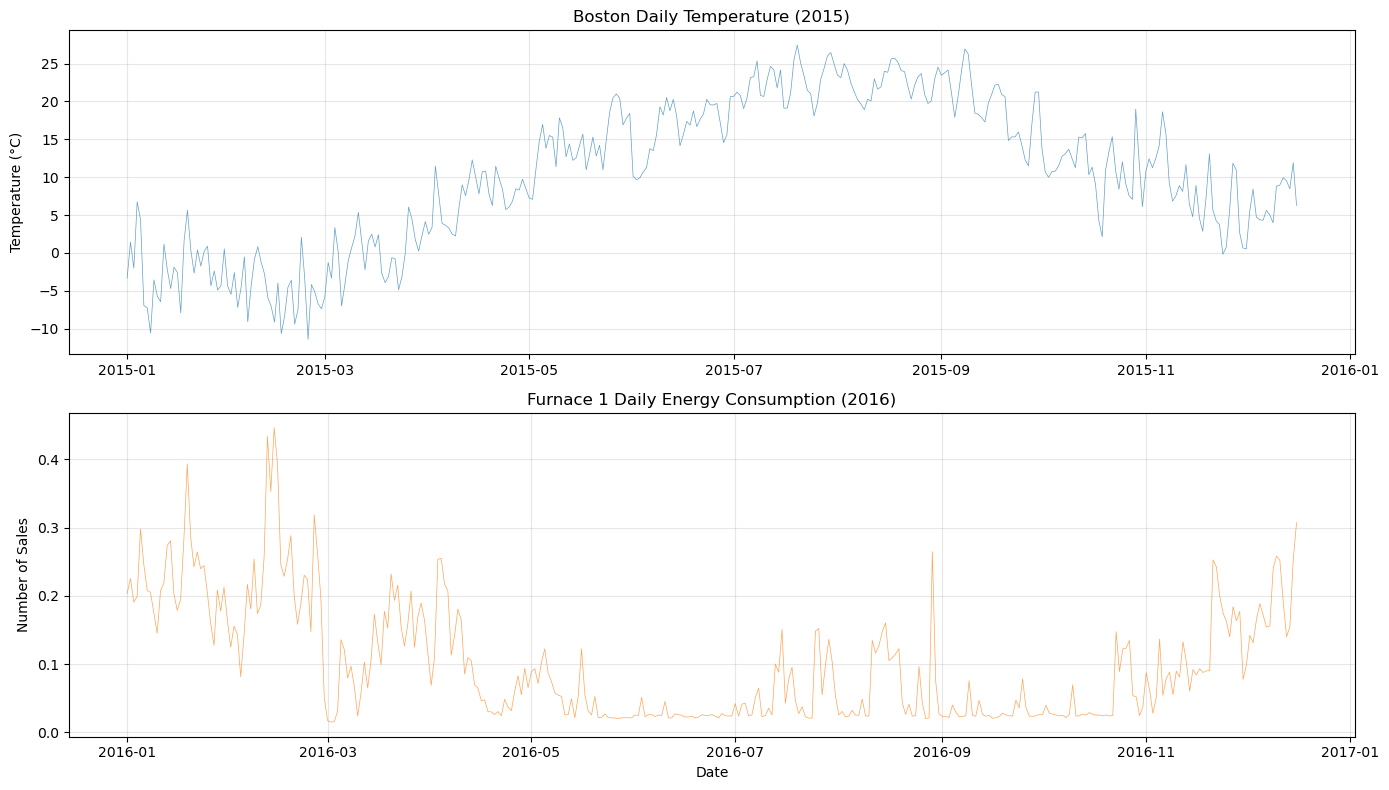

In [4]:
plot_both_dfs(
    temp_df[(temp_df["ds"] >= "2015-01-01") & (temp_df["ds"] <= "2015-12-16")],
    smart_home_df[smart_home_df["series"] == "Furnace 1 [kW]"],
    title1="Boston Daily Temperature (2015)",
    title2="Furnace 1 Daily Energy Consumption (2016)",
)

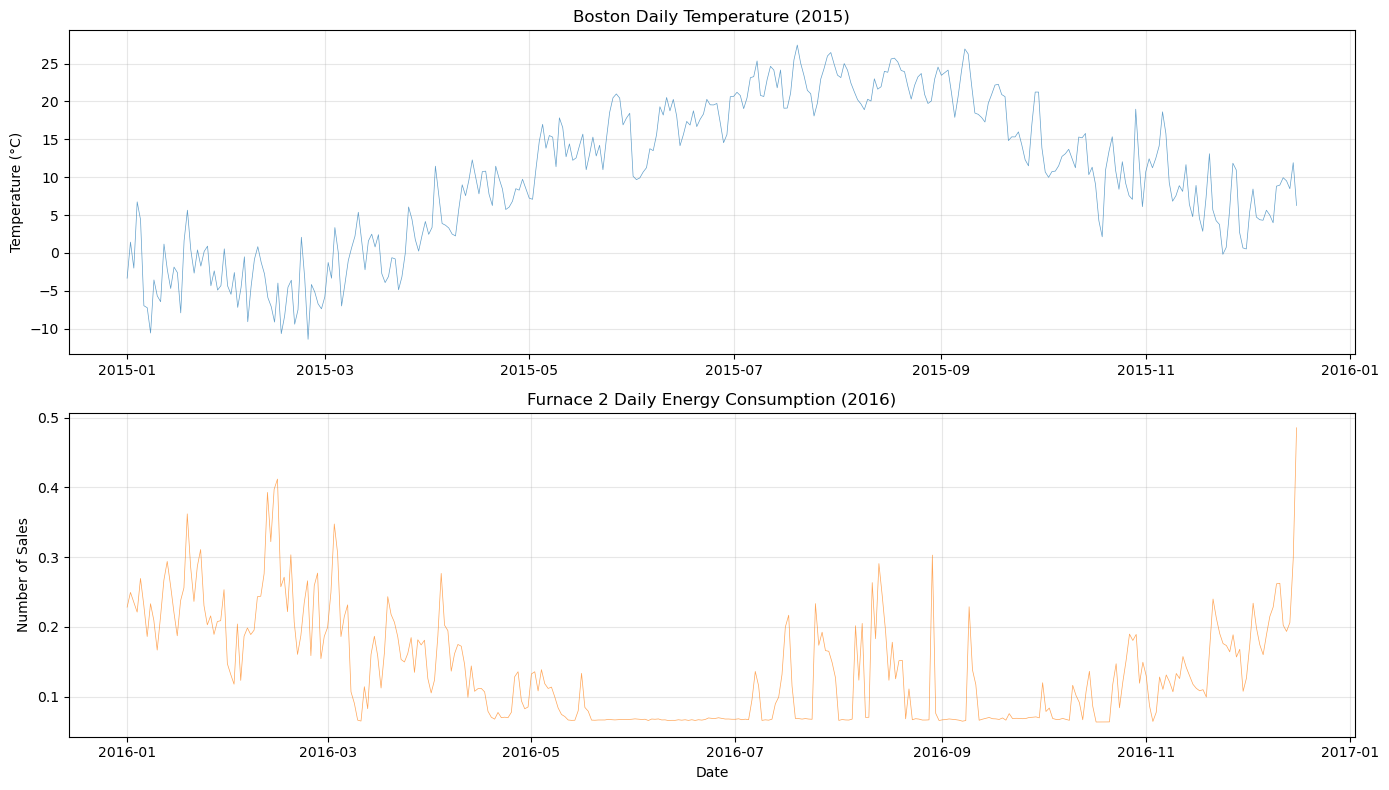

In [5]:
plot_both_dfs(
    temp_df[(temp_df["ds"] >= "2015-01-01") & (temp_df["ds"] <= "2015-12-16")],
    smart_home_df[smart_home_df["series"] == "Furnace 2 [kW]"],
    title1="Boston Daily Temperature (2015)",
    title2="Furnace 2 Daily Energy Consumption (2016)",
)

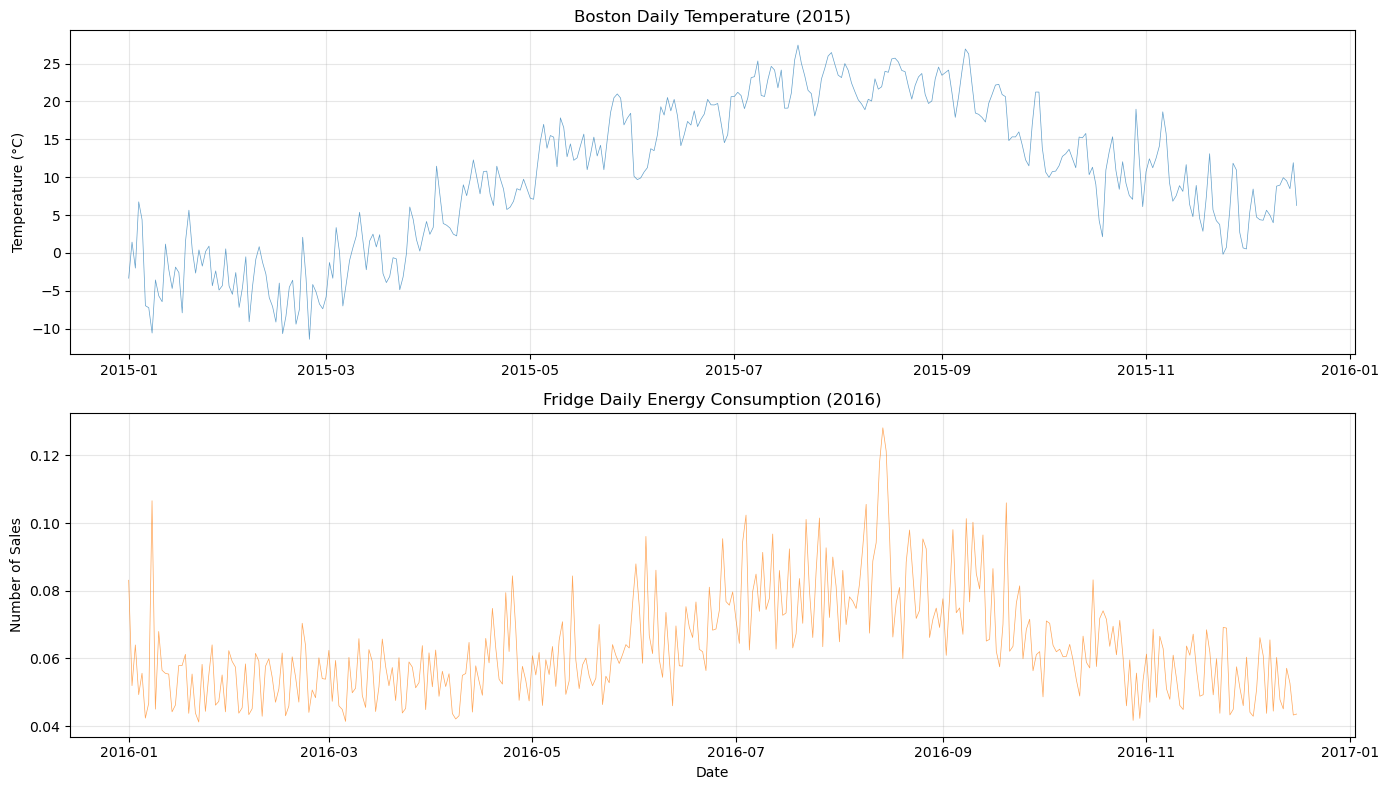

In [6]:
plot_both_dfs(
    temp_df[(temp_df["ds"] >= "2015-01-01") & (temp_df["ds"] <= "2015-12-16")],
    smart_home_df[smart_home_df["series"] == "Fridge [kW]"],
    title1="Boston Daily Temperature (2015)",
    title2="Fridge Daily Energy Consumption (2016)",
)

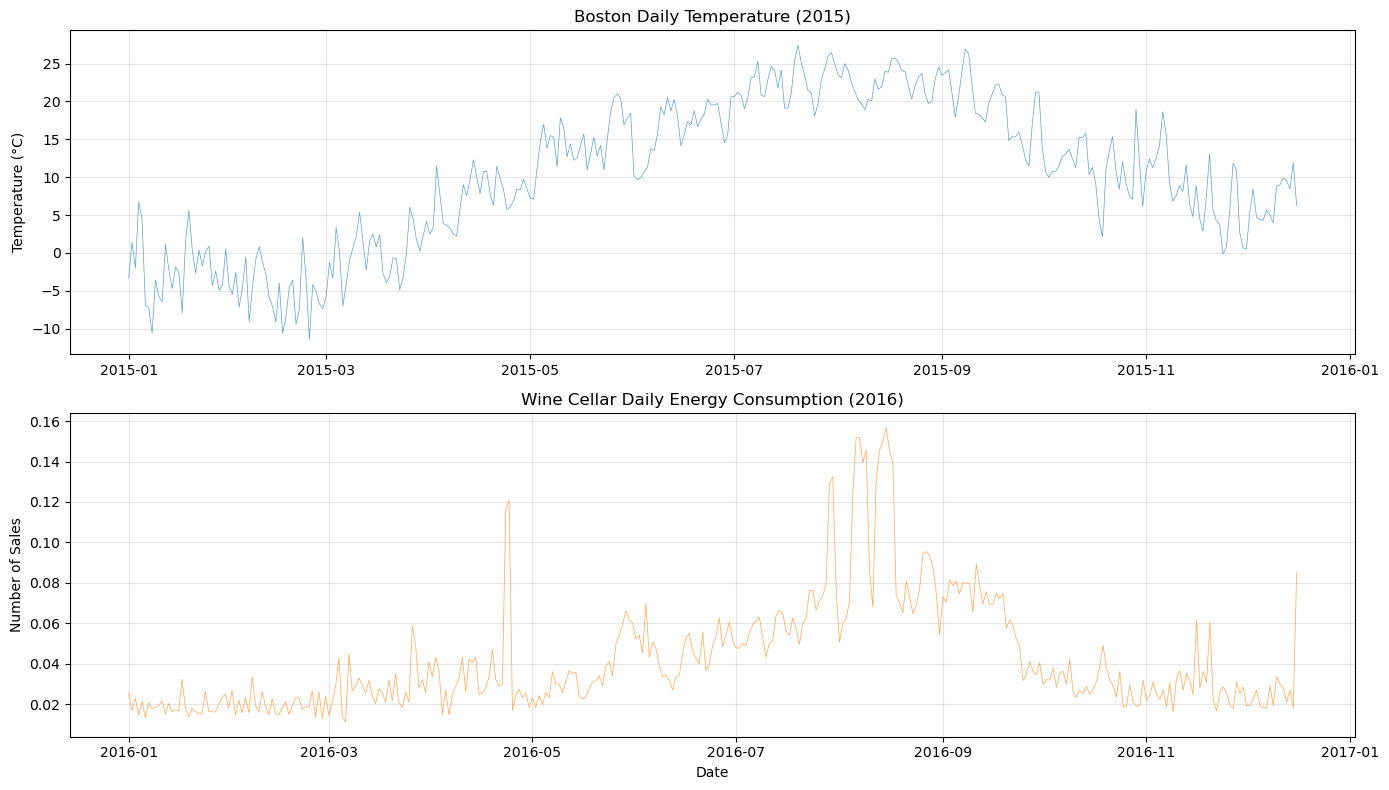

In [7]:
plot_both_dfs(
    temp_df[(temp_df["ds"] >= "2015-01-01") & (temp_df["ds"] <= "2015-12-16")],
    smart_home_df[smart_home_df["series"] == "Wine cellar [kW]"],
    title1="Boston Daily Temperature (2015)",
    title2="Wine Cellar Daily Energy Consumption (2016)",
)

## 2. Training the base temperature model

Next, we will train a base model on the temperature data to capture the yearly seasonality patterns. We will use a FourierSeasonality component to model the yearly seasonality. We use a flat trend component assuming that there is no significant trend in the temperature data. We center the flat trend around 0.5 assuming that the average temperature is around 0.5 (after scaling), with a small standard deviation to correct for our bias. We will use a Bayesian workflow to check if the model is flexible enough to capture the seasonality patterns in the temperature data, but not too flexible to overfit the data.

### 2.1 Prior predictive checks

We start by doing a prior predictive check to see if our model can generate data that resembles the observed temperature data before its fitted to the data. We also calculate the prior predictive coverage i.e. we calculate the percentage of prior predictive samples that fall within a fixed interval around the observed data.

Output()

Sampling: [fs_0 - beta, ft_0 - intercept, obs, sigma]


Prior predictive coverage: 0.4354056029232643


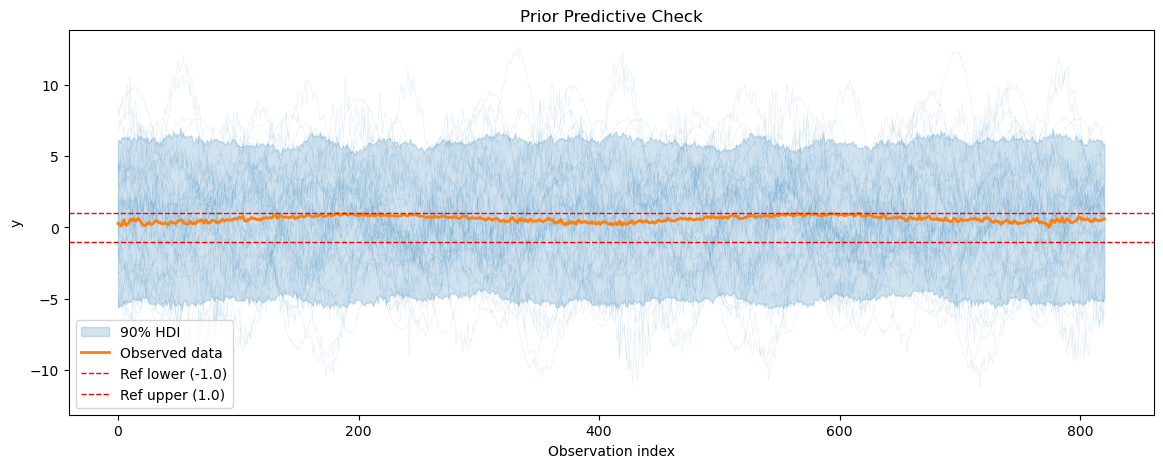

In [8]:
def create_temp_model():
    return FlatTrend(intercept_mean=0.5, intercept_sd=0.1) + FourierSeasonality(
        period=365.25, series_order=5, beta_sd=1.5
    )

temp_model = create_temp_model()
temp_model.fit(temp_df, scaler="minmax", method="mapx")
temp_prior_pred = temp_model.sample_prior_predictive()
plot_prior_predictive(
    temp_prior_pred, data=temp_model.data, show_hdi=True, show_ref_lines=True
)
print(f"Prior predictive coverage: {prior_predictive_coverage(temp_prior_pred)}")

### 2.2 MCMC sampling and diagnostics

After checking the prior predictive distribution, we proceed to fit the model to the temperature data using NUTS sampling. We will run the sampler for 1000 samples and check the diagnostics to ensure that the sampler has converged and that we have enough effective samples for our parameters. We will check the trace plots, the R-hat values, the effective sample size, the energy plot for our parameters to ensure that our model has been fitted properly to the data.

In [9]:
temp_model = create_temp_model()
temp_model.fit(temp_df, scaler="minmax", method="nuts")

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ft_0 - intercept, fs_0 - beta, sigma]
/home/jovan/miniconda3/envs/vangja20/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/jovan/miniconda3/envs/vangja20/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [10]:
temp_summary = temp_model.convergence_summary()
temp_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ft_0 - intercept,0.628,0.003,0.622,0.634,0.0,0.0,5442.0,3116.0,1.0
fs_0 - beta[0],-0.121,0.004,-0.129,-0.112,0.0,0.0,6421.0,3270.0,1.0
fs_0 - beta[1],-0.228,0.005,-0.237,-0.220,0.0,0.0,5856.0,3332.0,1.0
fs_0 - beta[2],-0.011,0.004,-0.020,-0.003,0.0,0.0,5067.0,3065.0,1.0
fs_0 - beta[3],0.008,0.004,-0.000,0.016,0.0,0.0,5853.0,3277.0,1.0
fs_0 - beta[4],-0.017,0.004,-0.026,-0.009,0.0,0.0,5473.0,3218.0,1.0
fs_0 - beta[5],0.013,0.004,0.005,0.021,0.0,0.0,5771.0,3297.0,1.0
fs_0 - beta[6],-0.005,0.005,-0.013,0.004,0.0,0.0,5671.0,3303.0,1.0
fs_0 - beta[7],0.006,0.004,-0.002,0.015,0.0,0.0,5382.0,2736.0,1.0
fs_0 - beta[8],-0.007,0.004,-0.015,0.001,0.0,0.0,5262.0,3162.0,1.0


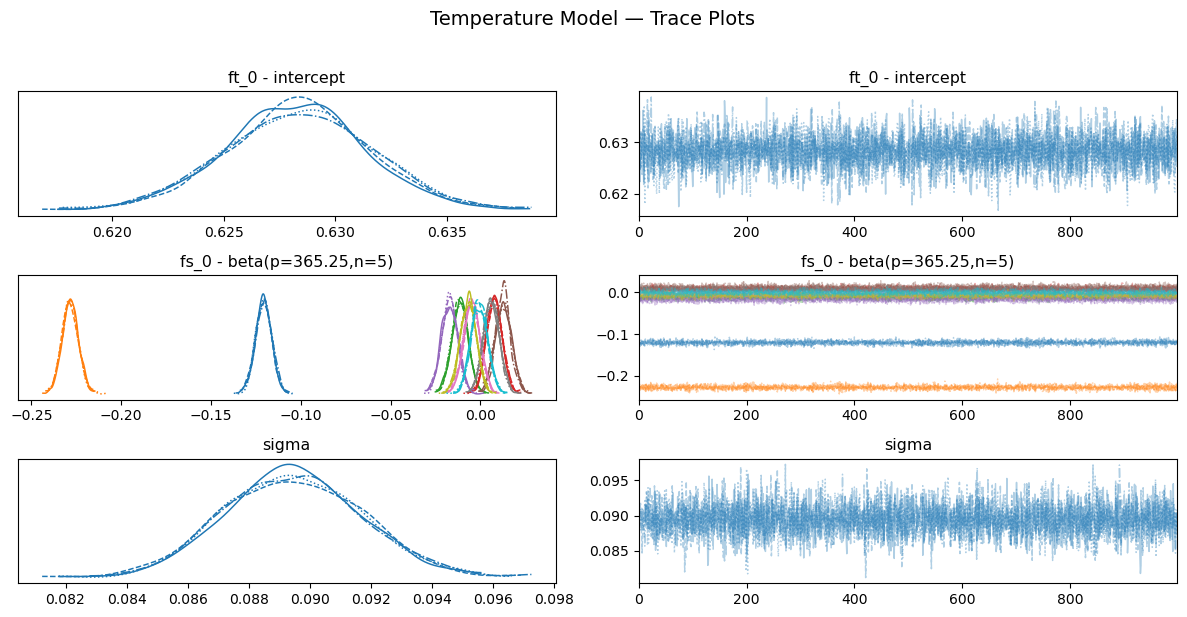

In [11]:
temp_model.plot_trace()
plt.suptitle("Temperature Model — Trace Plots", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

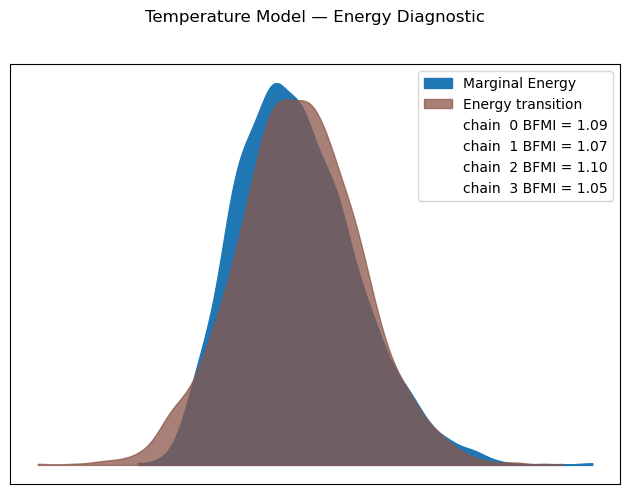

In [12]:
temp_model.plot_energy()
plt.suptitle("Temperature Model — Energy Diagnostic", y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Posterior predictive checks
After fitting the model, we will perform posterior predictive checks to evaluate how well our model can reproduce the observed temperature data.

Sampling: [obs]


Output()

<Axes: title={'center': 'Posterior Predictive Check'}, xlabel='Observation index', ylabel='y'>

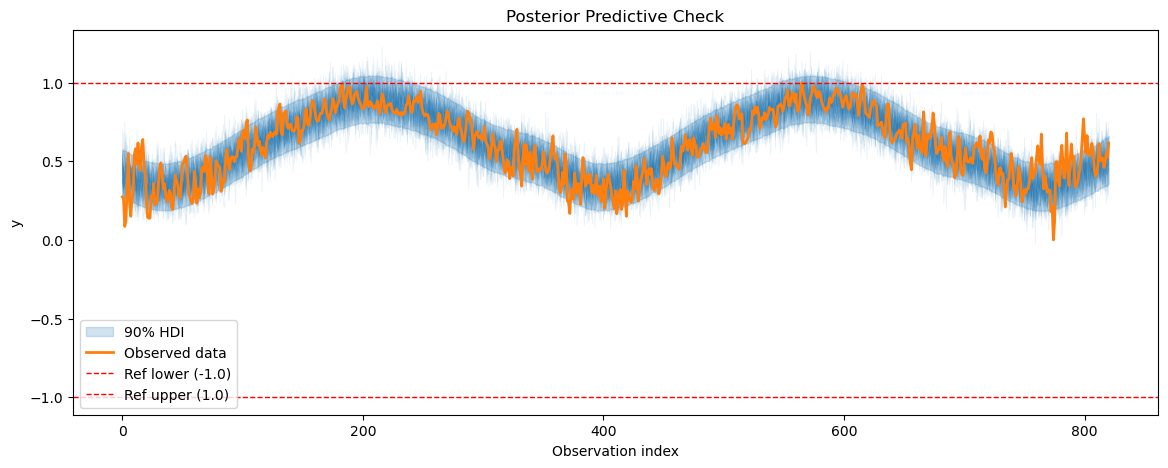

In [13]:
temp_posterior_pred = temp_model.sample_posterior_predictive()
plot_posterior_predictive(
    temp_posterior_pred, data=temp_model.data, show_hdi=True, show_ref_lines=True
)

## 3. Training the energy consumption model

After training the base temperature model, we will use the learned seasonality patterns from the temperature model to inform the energy consumption model. We will use a similar model structure for the energy consumption data, but we will include the temperature model's seasonality component as a prior for the energy consumption model's seasonality component. This way, we can transfer the knowledge about the seasonality patterns from the temperature model to the energy consumption model, which can help improve the forecasts for the energy consumption data, especially given the limited training data for the energy consumption series.

### 3.1 Prior predictive checks
We will start by doing a prior predictive check for the energy consumption model to see if it can generate data that resembles the observed energy consumption data before fitting it to the data.

In [14]:
smh_train_df = smart_home_df[smart_home_df["ds"] < "2016-04-01"]
smh_test_df = smart_home_df[smart_home_df["ds"] >= "2016-04-01"]

test_temp_df = load_kaggle_temperature(
    city="Boston", start_date="2016-04-01", end_date="2016-12-16", freq="D"
)
temp_df["series"] = "Temperature"
test_temp_df["series"] = "Temperature"

train_df = pd.concat([smh_train_df, temp_df], ignore_index=True)
test_df = pd.concat([smh_test_df, test_temp_df], ignore_index=True)


def create_smh_model():
    return (
        FlatTrend(intercept_mean=0.5, intercept_sd=0.1, pool_type="individual")
        + UniformConstant(lower=-1, upper=1, pool_type="partial", shrinkage_strength=1)
        * FourierSeasonality(
            period=365.25,
            series_order=5,
            beta_sd=1.5,
            tune_method="prior_from_idata",
            pool_type="partial",
            loss_factor_for_tune=1,
            shrinkage_strength=1,
        )
        + FourierSeasonality(
            period=7,
            series_order=3,
            beta_sd=1.5,
            pool_type="partial",
            shrinkage_strength=1,
        )
    )


smart_home_model = create_smh_model()
smart_home_model.fit(
    train_df,
    scaler="minmax",
    method="mapx",
    scale_mode="individual",
    sigma_pool_type="individual",
    t_scale_params=temp_model.t_scale_params,
    idata=temp_model.trace,
)
smart_home_prior_pred = smart_home_model.sample_prior_predictive()

Output()

/home/jovan/repos/vangja/src/vangja/time_series.py:932: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  return pm.sample_prior_predictive(samples=samples)
Sampling: [fs_0 - beta_sigma, fs_0 - beta_z_offset, fs_1 - beta_shared, fs_1 - beta_sigma, fs_1 - beta_z_offset, ft_0 - intercept, obs, priors, sigma, uc_0 - c_offset, uc_0 - c_shared, uc_0 - c_sigma]


Prior predictive coverage (series 0): 0.412989010989011
Prior predictive coverage (series 1): 0.4197362637362637
Prior predictive coverage (series 2): 0.42002197802197805
Prior predictive coverage (series 3): 0.43358587088915956
Prior predictive coverage (series 4): 0.42443956043956044


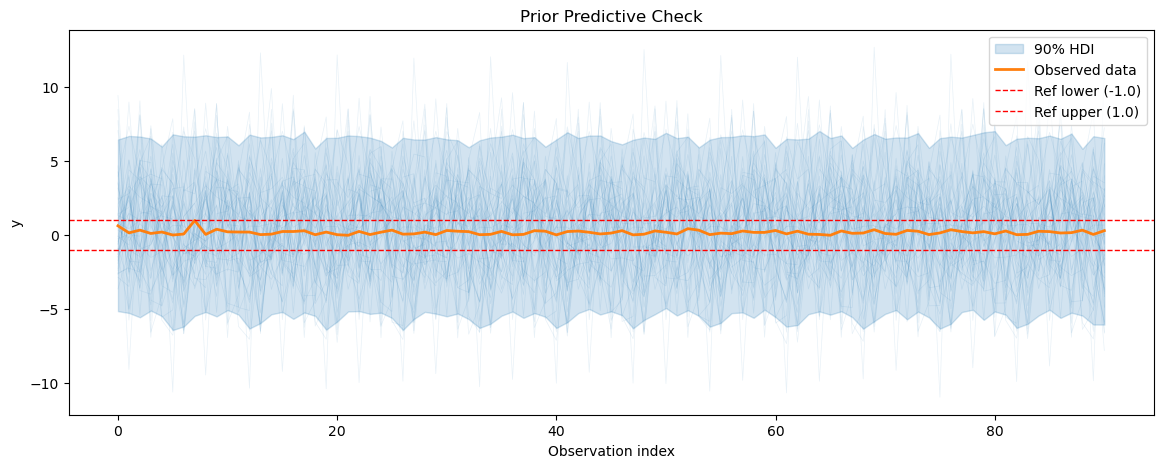

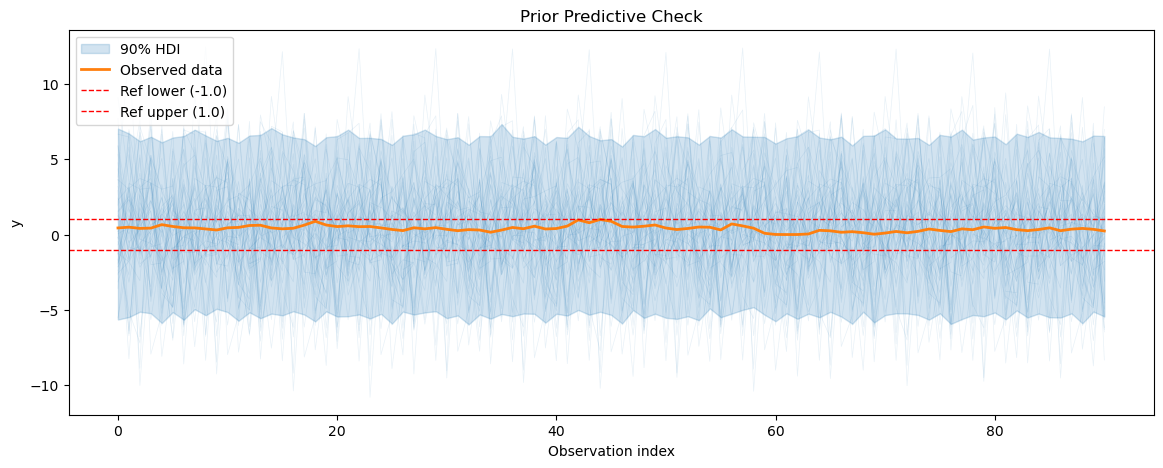

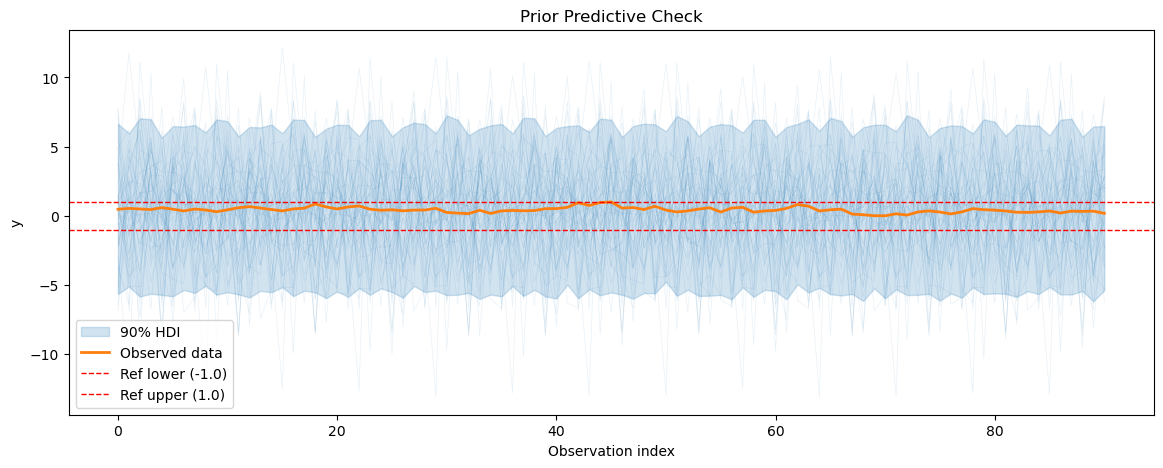

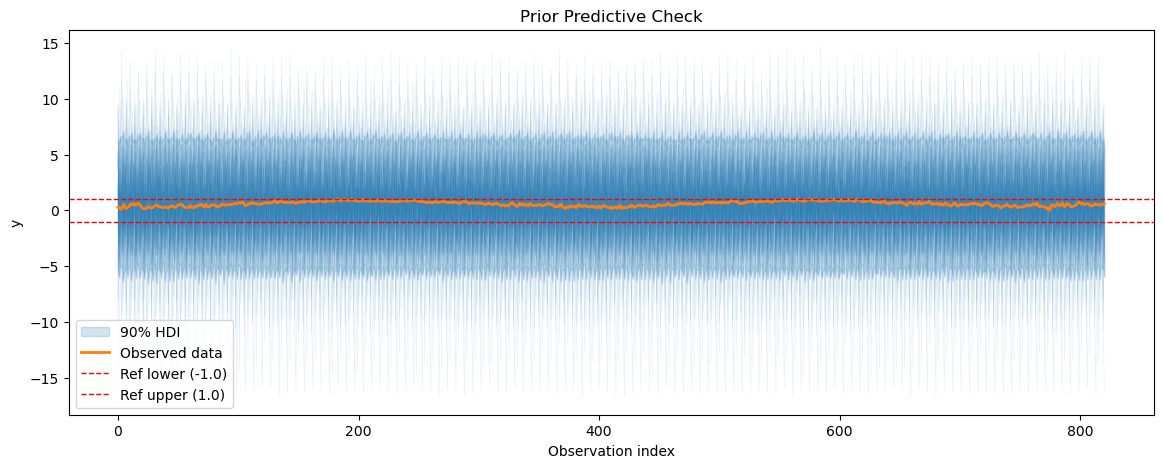

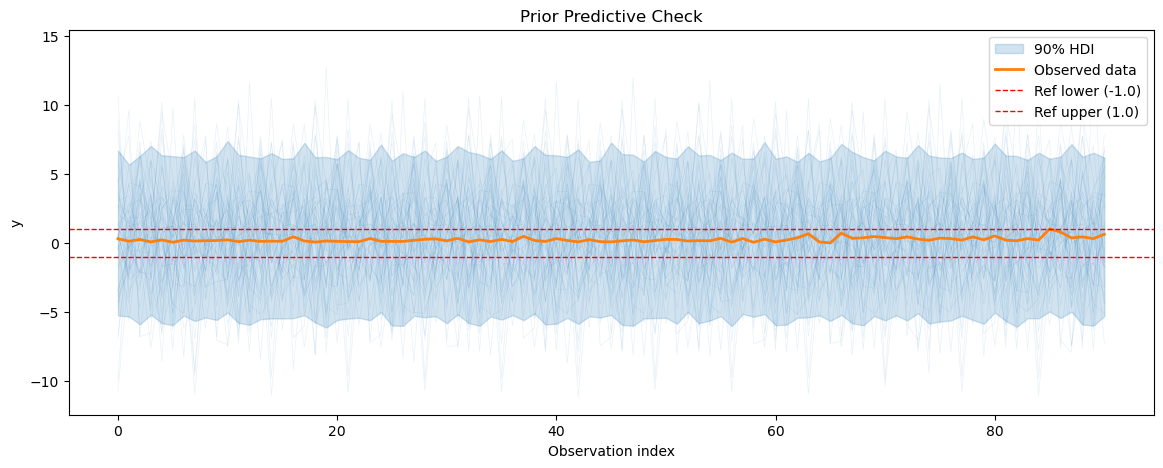

In [15]:
for series_idx in range(smart_home_model.n_groups):
    plot_prior_predictive(
        smart_home_prior_pred,
        data=smart_home_model.data,
        series_idx=series_idx,
        group=smart_home_model.group,
        show_hdi=True,
        show_ref_lines=True,
    )
    print(
        f"Prior predictive coverage (series {series_idx}): {prior_predictive_coverage(smart_home_prior_pred, series_idx=series_idx, group=smart_home_model.group)}"
    )

### 3.2 MCMC sampling and diagnostics

We do the similar MCMC sampling and diagnostics for the energy consumption model as we did for the temperature model. We will check the trace plots, R-hat values, effective sample size, and energy plot to ensure that our model has been fitted properly to the data. We will also calculate the metrics for the energy consumption model on the test set to evaluate its performance.

In [16]:
smart_home_model = create_smh_model()
smart_home_model.fit(
    train_df,
    scaler="minmax",
    method="nuts",
    scale_mode="individual",
    sigma_pool_type="individual",
    t_scale_params=temp_model.t_scale_params,
    idata=temp_model.trace,
)
future = smart_home_model.predict_uncertainty(horizon=365)
smart_home_model_metrics = metrics(test_df, future, pool_type="partial")
smart_home_model_metrics

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [priors, ft_0 - intercept, uc_0 - c_shared, uc_0 - c_sigma, uc_0 - c_offset, fs_0 - beta_sigma, fs_0 - beta_z_offset, fs_1 - beta_shared, fs_1 - beta_sigma, fs_1 - beta_z_offset, sigma]
/home/jovan/miniconda3/envs/vangja20/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/home/jovan/miniconda3/envs/vangja20/lib/python3.13/multiprocessing/popen_fork.py:67: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1252 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
/home/jovan/repos/vangja/src/vangja/time_series.py:582: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = posterior.dims["chain"]
/home/jovan/repos/vangja/src/vangja/time_series.py:583: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = posterior.dims["draw"]


,mse,rmse,mae,mape
Fridge [kW],0.000165,0.012855,0.010292,0.162343
Furnace 1 [kW],0.006084,0.078000,0.071144,2.135425
Furnace 2 [kW],0.004160,0.064499,0.055699,0.629320
Temperature,11.775991,3.431616,2.678049,0.459226
Wine cellar [kW],0.000805,0.028374,0.017642,0.313271


In [17]:
smart_home_summary = smart_home_model.convergence_summary()
smart_home_summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
priors[0],0.548,0.743,-0.833,1.957,0.011,0.012,4438.0,2623.0,1.0
priors[1],0.692,0.549,-0.266,1.769,0.010,0.009,3325.0,2728.0,1.0
priors[2],0.070,0.773,-1.485,1.463,0.011,0.014,4694.0,2670.0,1.0
priors[3],-0.343,0.774,-1.785,1.113,0.012,0.013,4268.0,3017.0,1.0
priors[4],-0.191,0.771,-1.661,1.214,0.011,0.014,5161.0,3087.0,1.0
...,...,...,...,...,...,...,...,...,...
"fs_1 - beta[4, 1]",-0.009,0.015,-0.041,0.016,0.000,0.000,3643.0,3089.0,1.0
"fs_1 - beta[4, 2]",-0.004,0.020,-0.044,0.031,0.000,0.000,4008.0,3007.0,1.0
"fs_1 - beta[4, 3]",0.012,0.018,-0.020,0.046,0.000,0.000,2301.0,3323.0,1.0
"fs_1 - beta[4, 4]",-0.003,0.015,-0.033,0.027,0.000,0.000,4182.0,3186.0,1.0


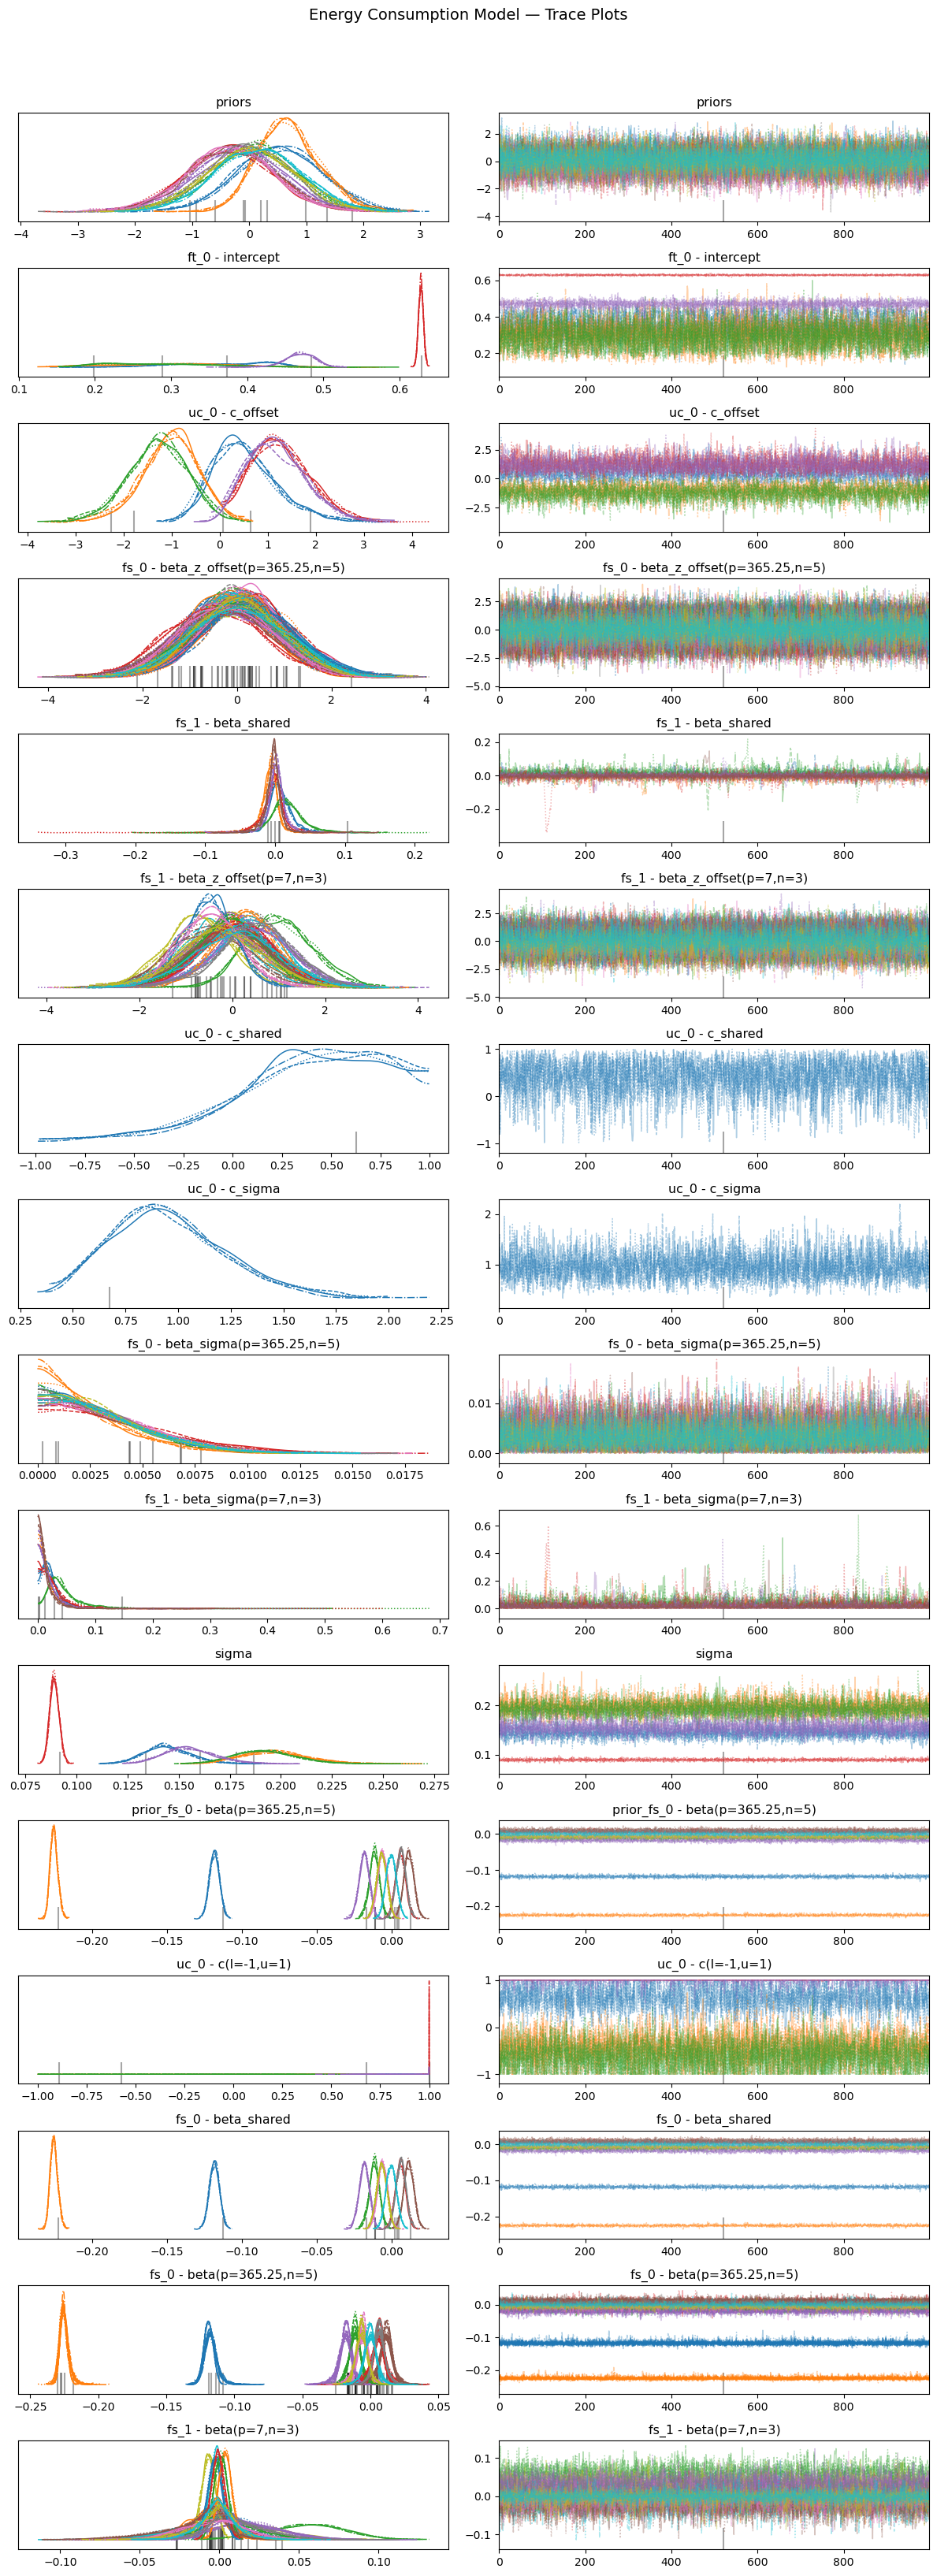

In [18]:
smart_home_model.plot_trace()
plt.suptitle("Energy Consumption Model — Trace Plots", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

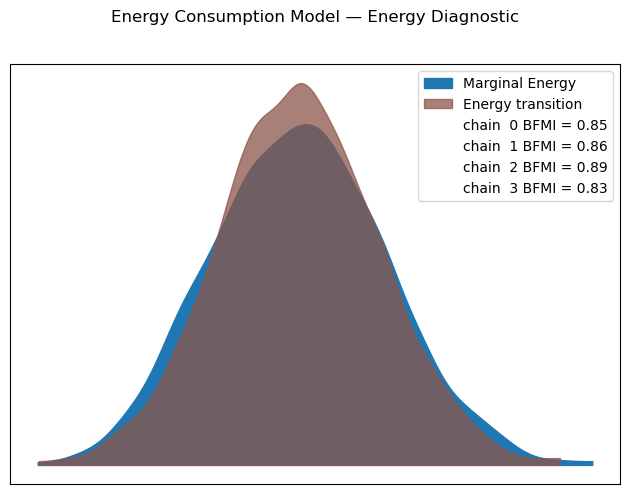

In [19]:
smart_home_model.plot_energy()
plt.suptitle("Energy Consumption Model — Energy Diagnostic", y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Posterior predictive checks
After fitting the energy consumption model, we will perform posterior predictive checks to evaluate how well our model can reproduce the observed energy consumption data.

/home/jovan/repos/vangja/src/vangja/time_series.py:968: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  return pm.sample_posterior_predictive(self.trace)
Sampling: [obs]


Output()

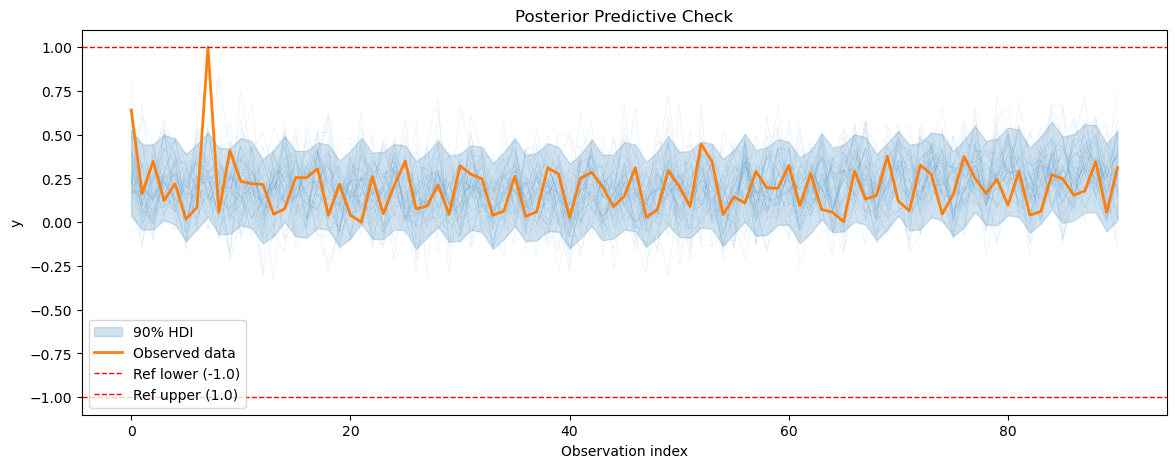

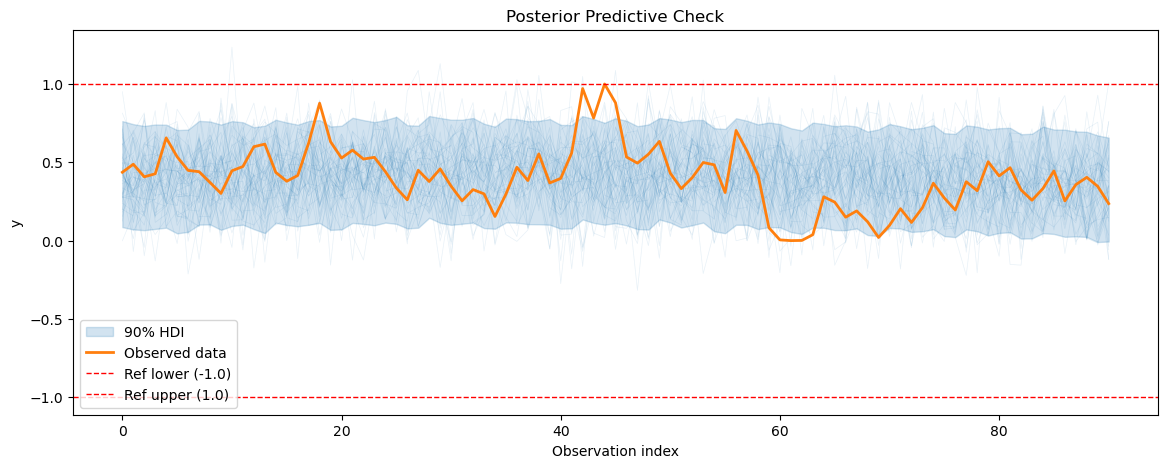

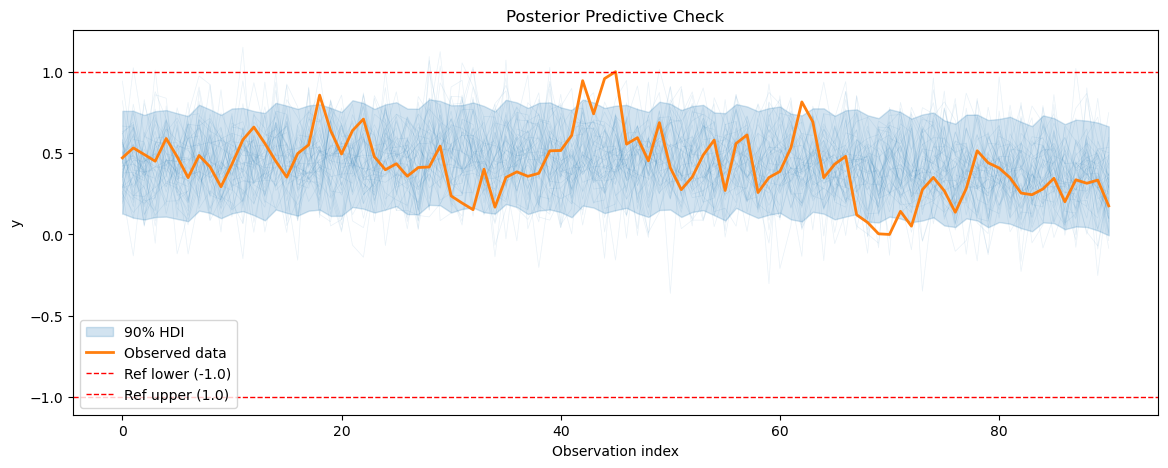

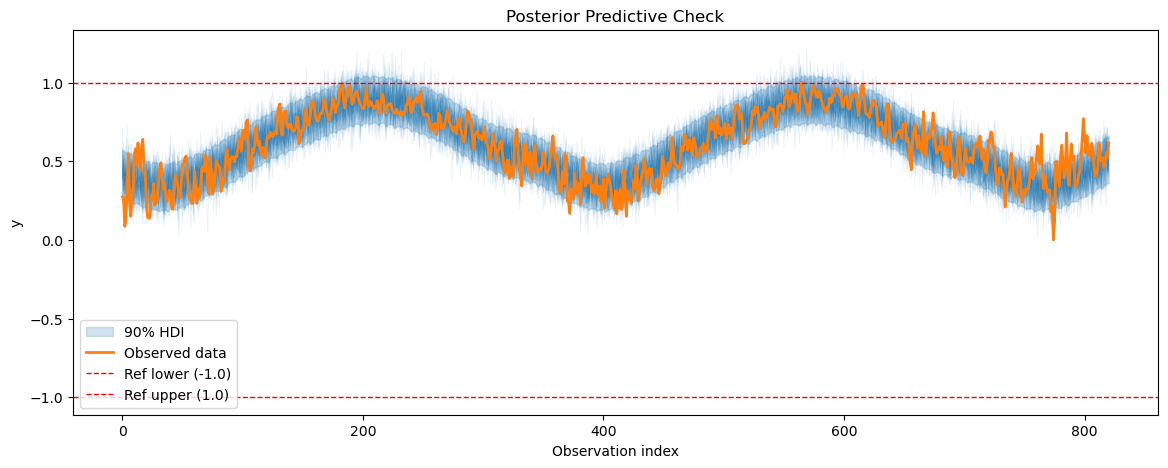

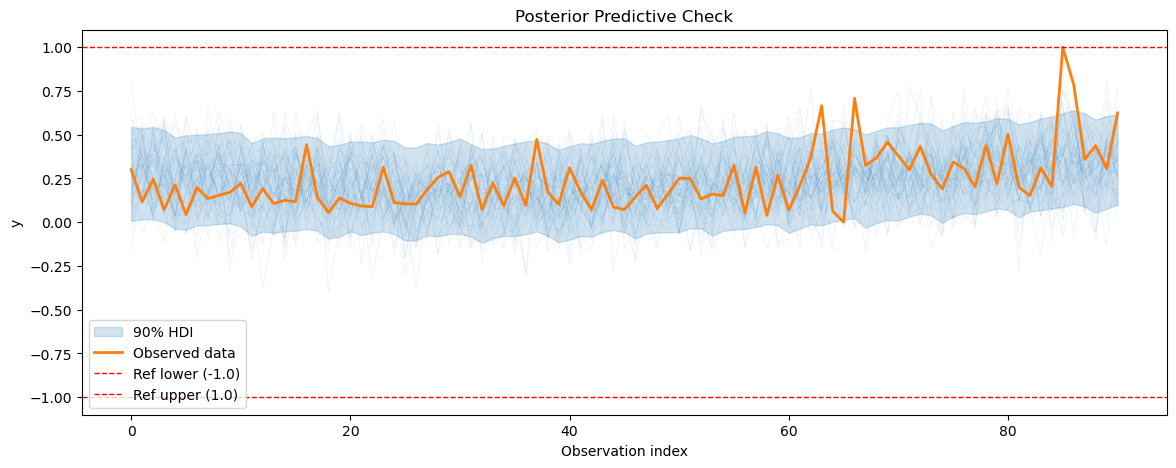

In [20]:
smh_posterior_pred = smart_home_model.sample_posterior_predictive()
for series_idx in range(smart_home_model.n_groups):
    plot_posterior_predictive(
        smh_posterior_pred,
        data=smart_home_model.data,
        series_idx=series_idx,
        group=smart_home_model.group,
        show_hdi=True,
        show_ref_lines=True,
    )

### 3.4 Plotting the forecasts
Finally, we will plot the forecasts for the energy consumption data along with the observed data to visualize how well our model is performing in terms of capturing the patterns in the energy consumption data and making accurate forecasts.

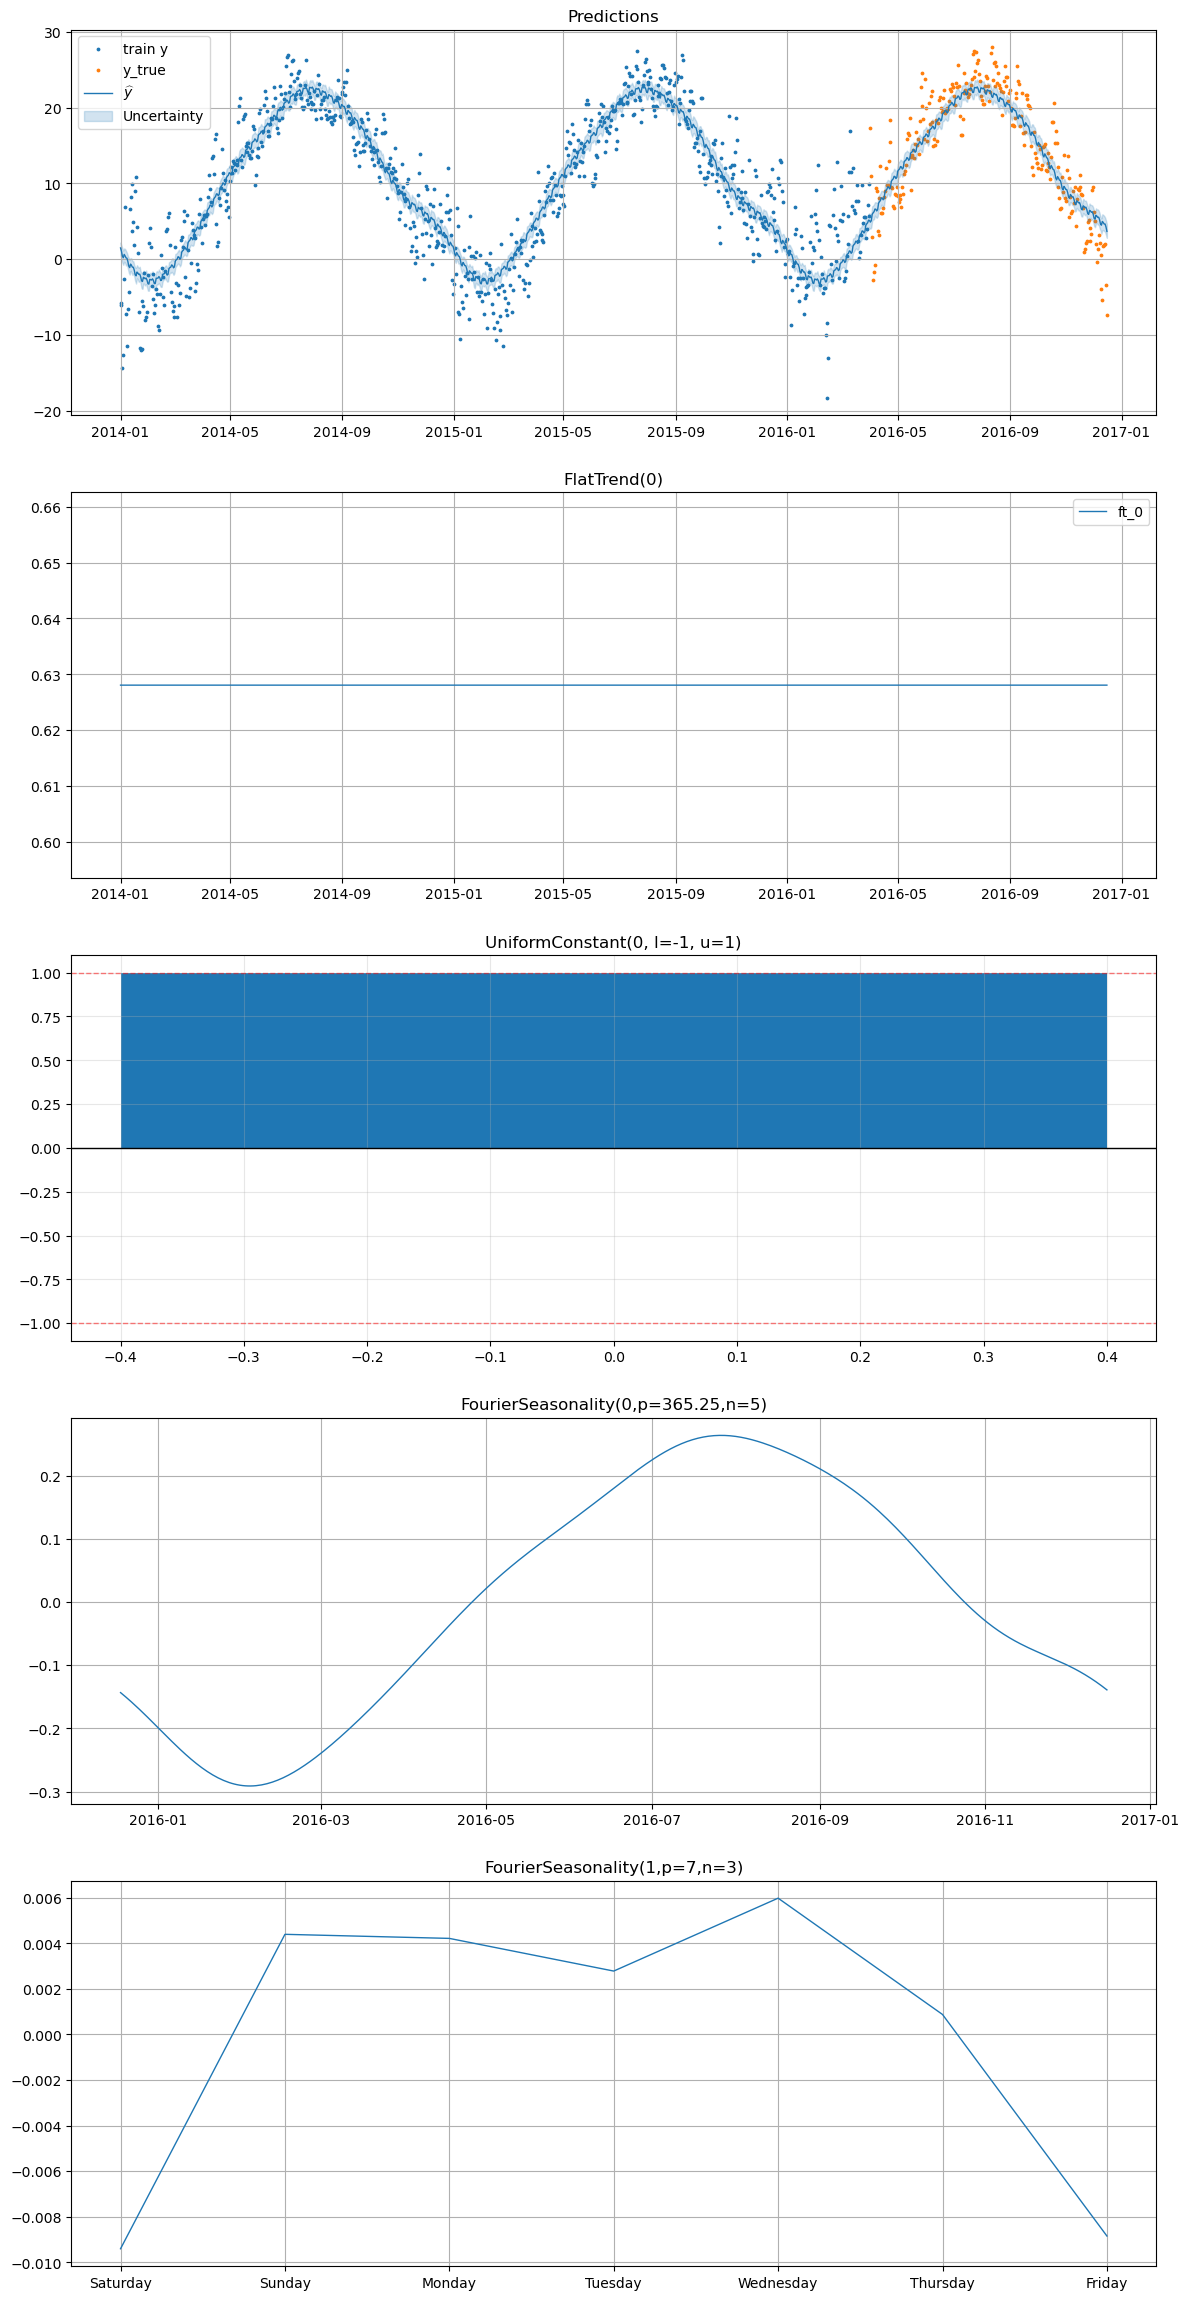

In [21]:
smart_home_model.plot(
    future,
    series="Temperature",
    y_true=test_df[
        (test_df["series"] == "Temperature") & (test_df["ds"] >= "2016-04-01")
    ],
)

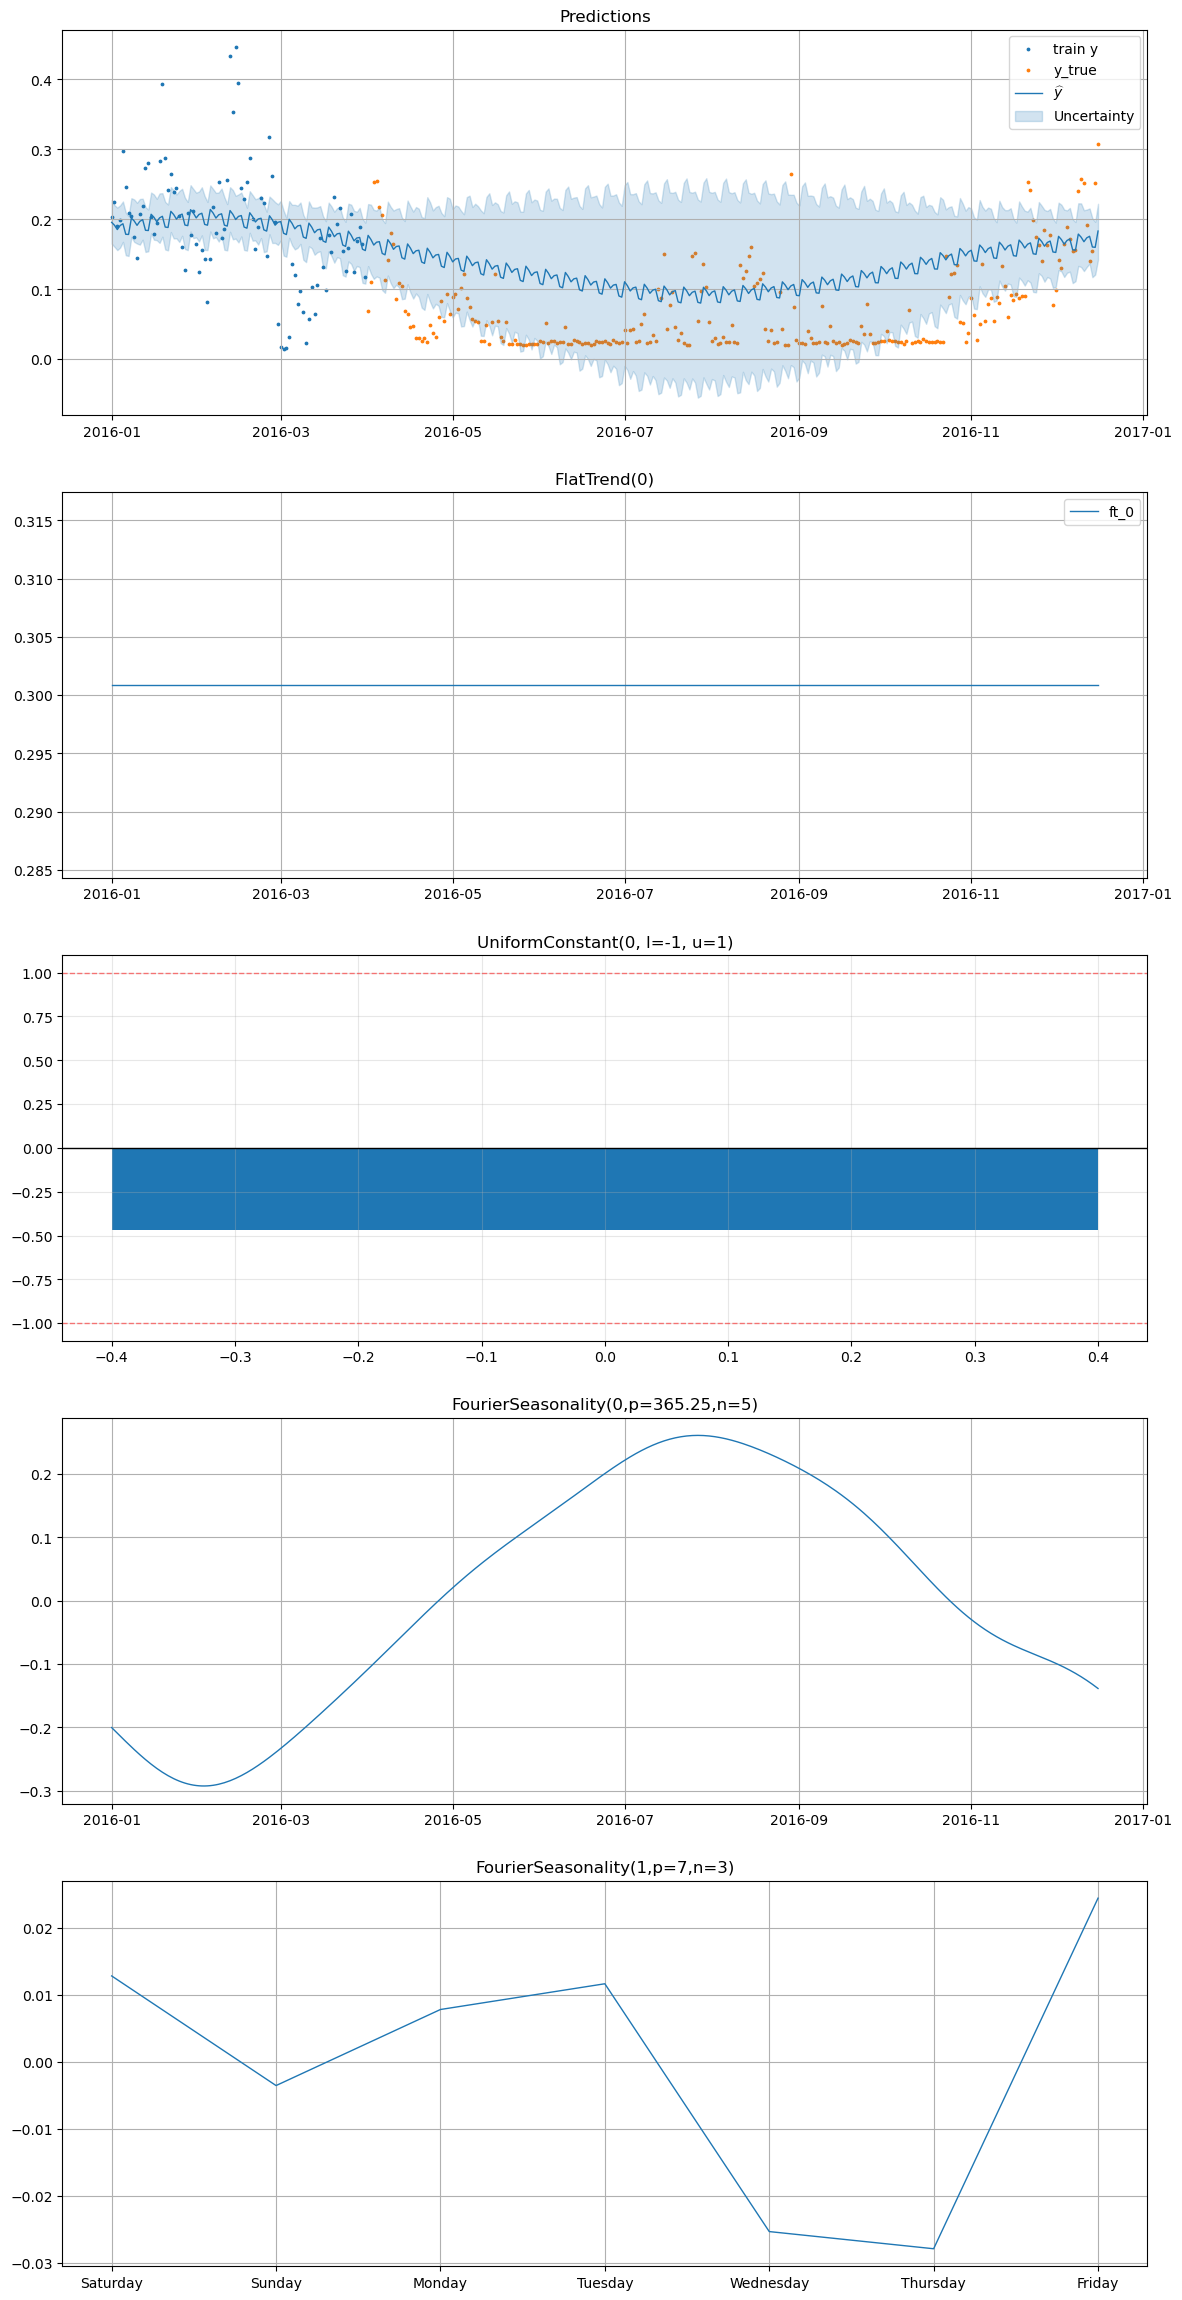

In [22]:
smart_home_model.plot(
    future,
    series="Furnace 1 [kW]",
    y_true=smart_home_df[
        (smart_home_df["series"] == "Furnace 1 [kW]")
        & (smart_home_df["ds"] >= "2016-04-01")
    ],
)

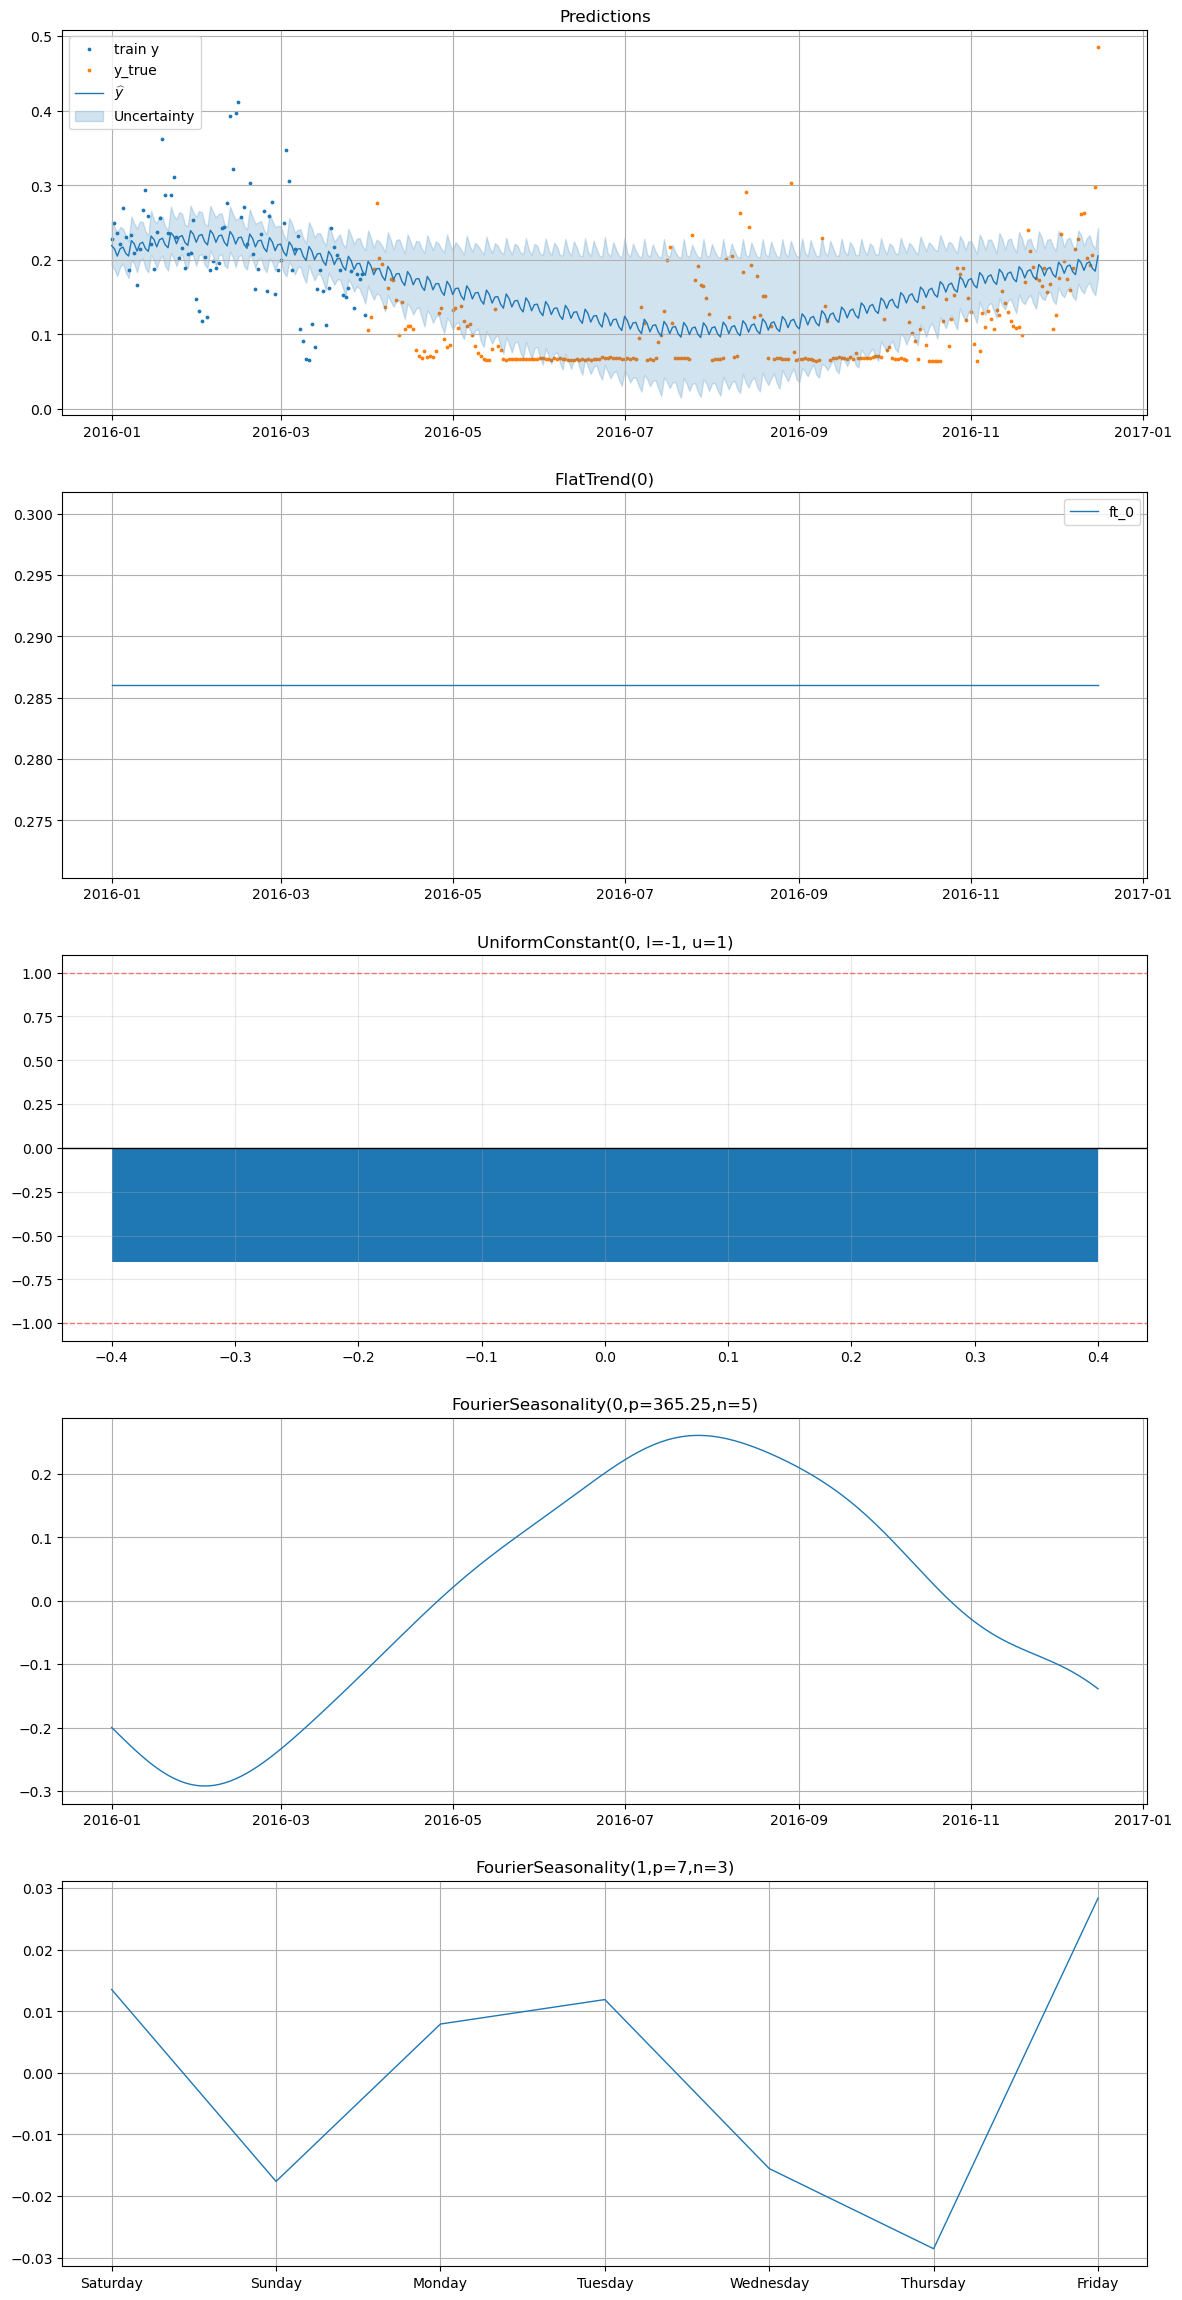

In [23]:
smart_home_model.plot(
    future,
    series="Furnace 2 [kW]",
    y_true=smart_home_df[
        (smart_home_df["series"] == "Furnace 2 [kW]")
        & (smart_home_df["ds"] >= "2016-04-01")
    ],
)

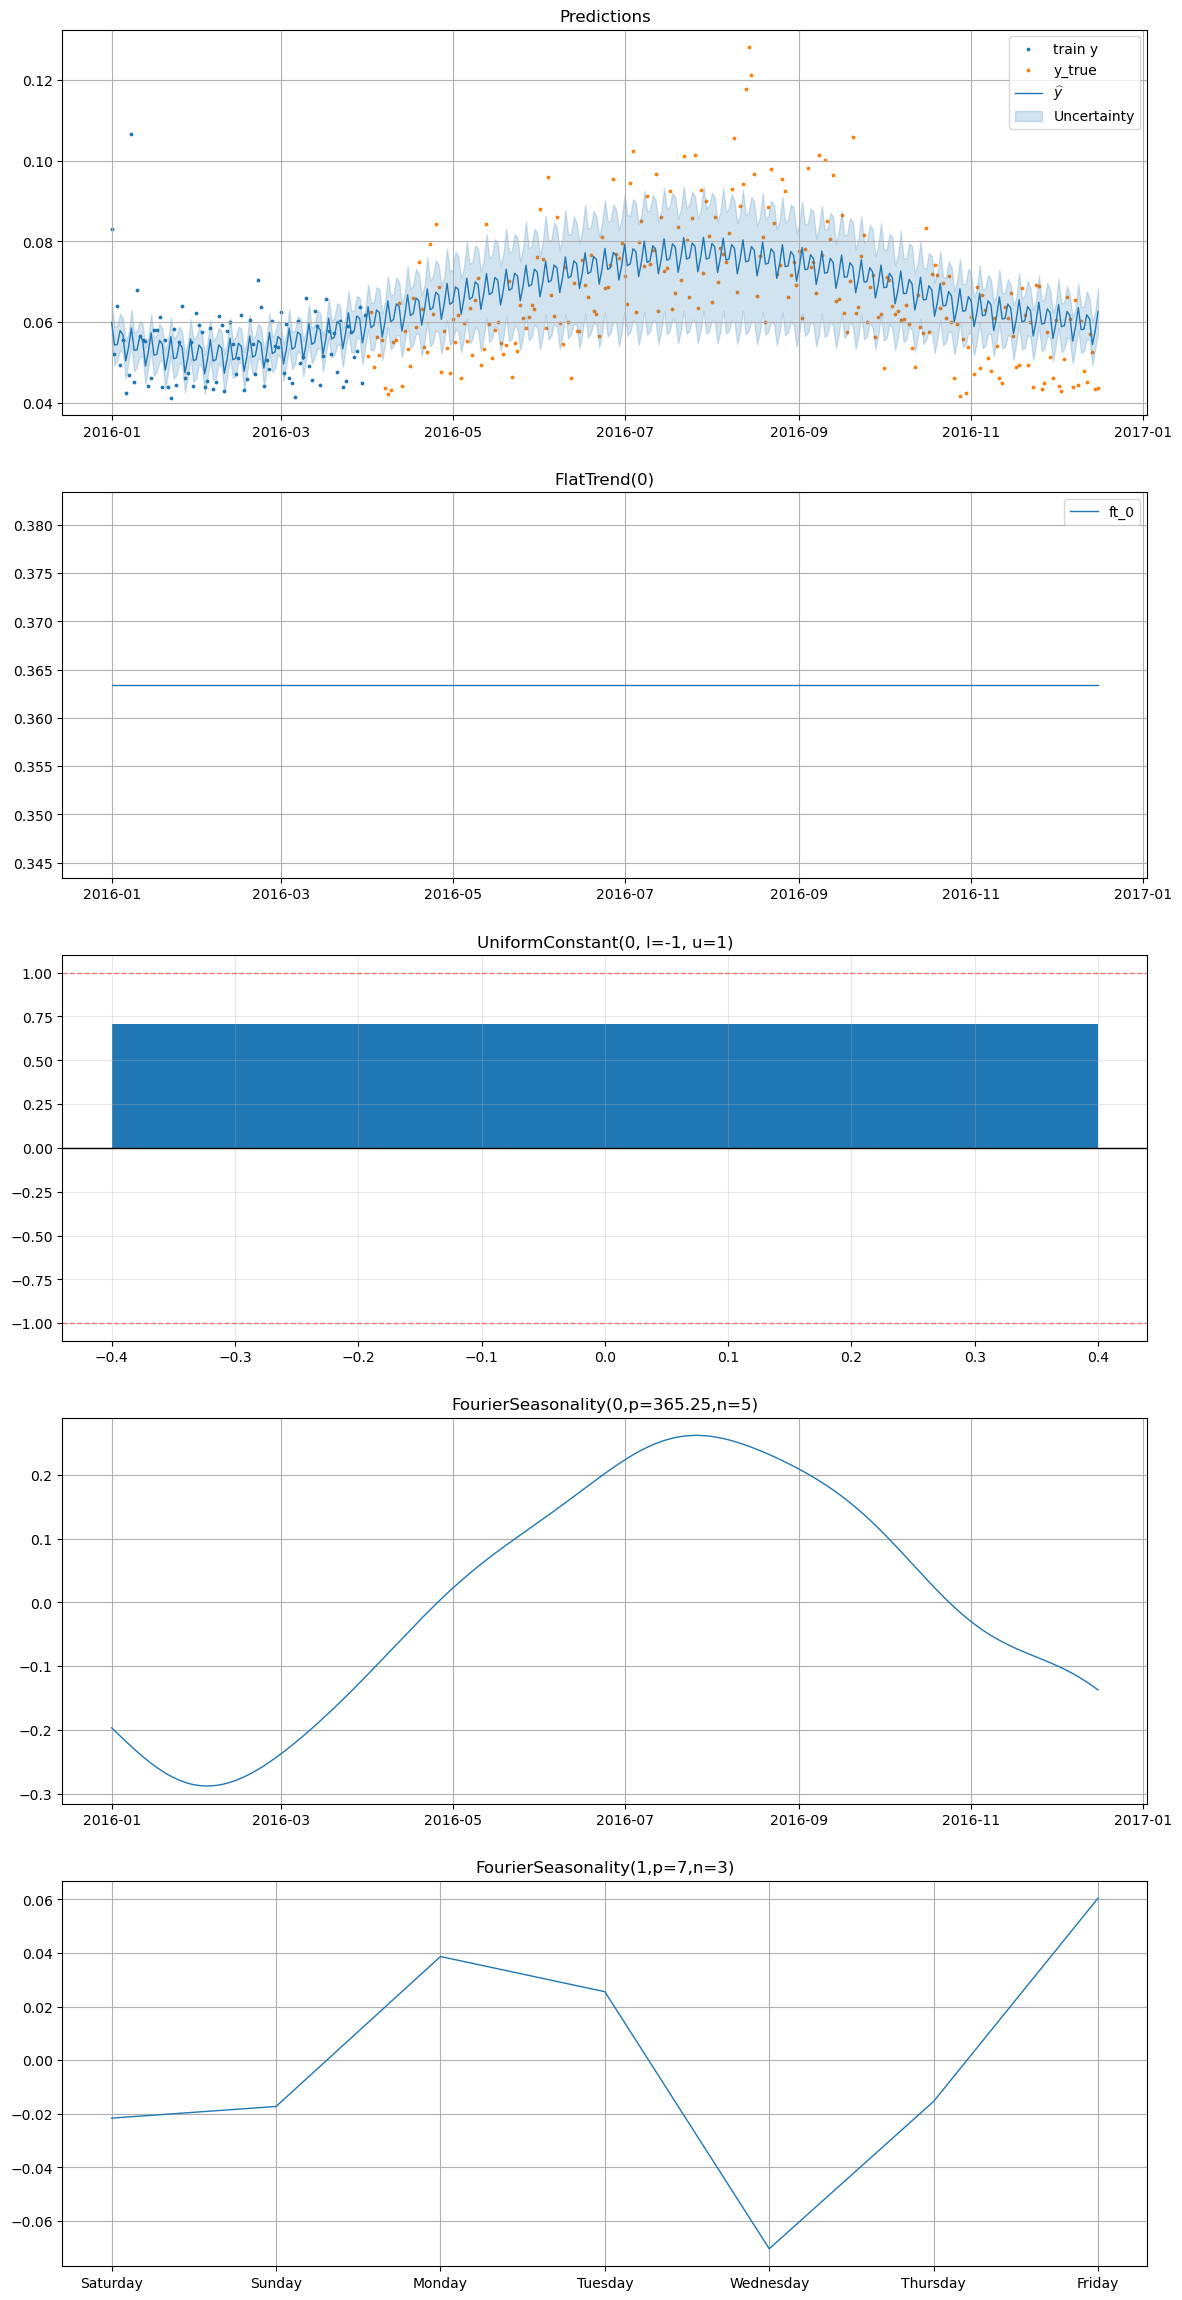

In [24]:
smart_home_model.plot(
    future,
    series="Fridge [kW]",
    y_true=smart_home_df[
        (smart_home_df["series"] == "Fridge [kW]")
        & (smart_home_df["ds"] >= "2016-04-01")
    ],
)

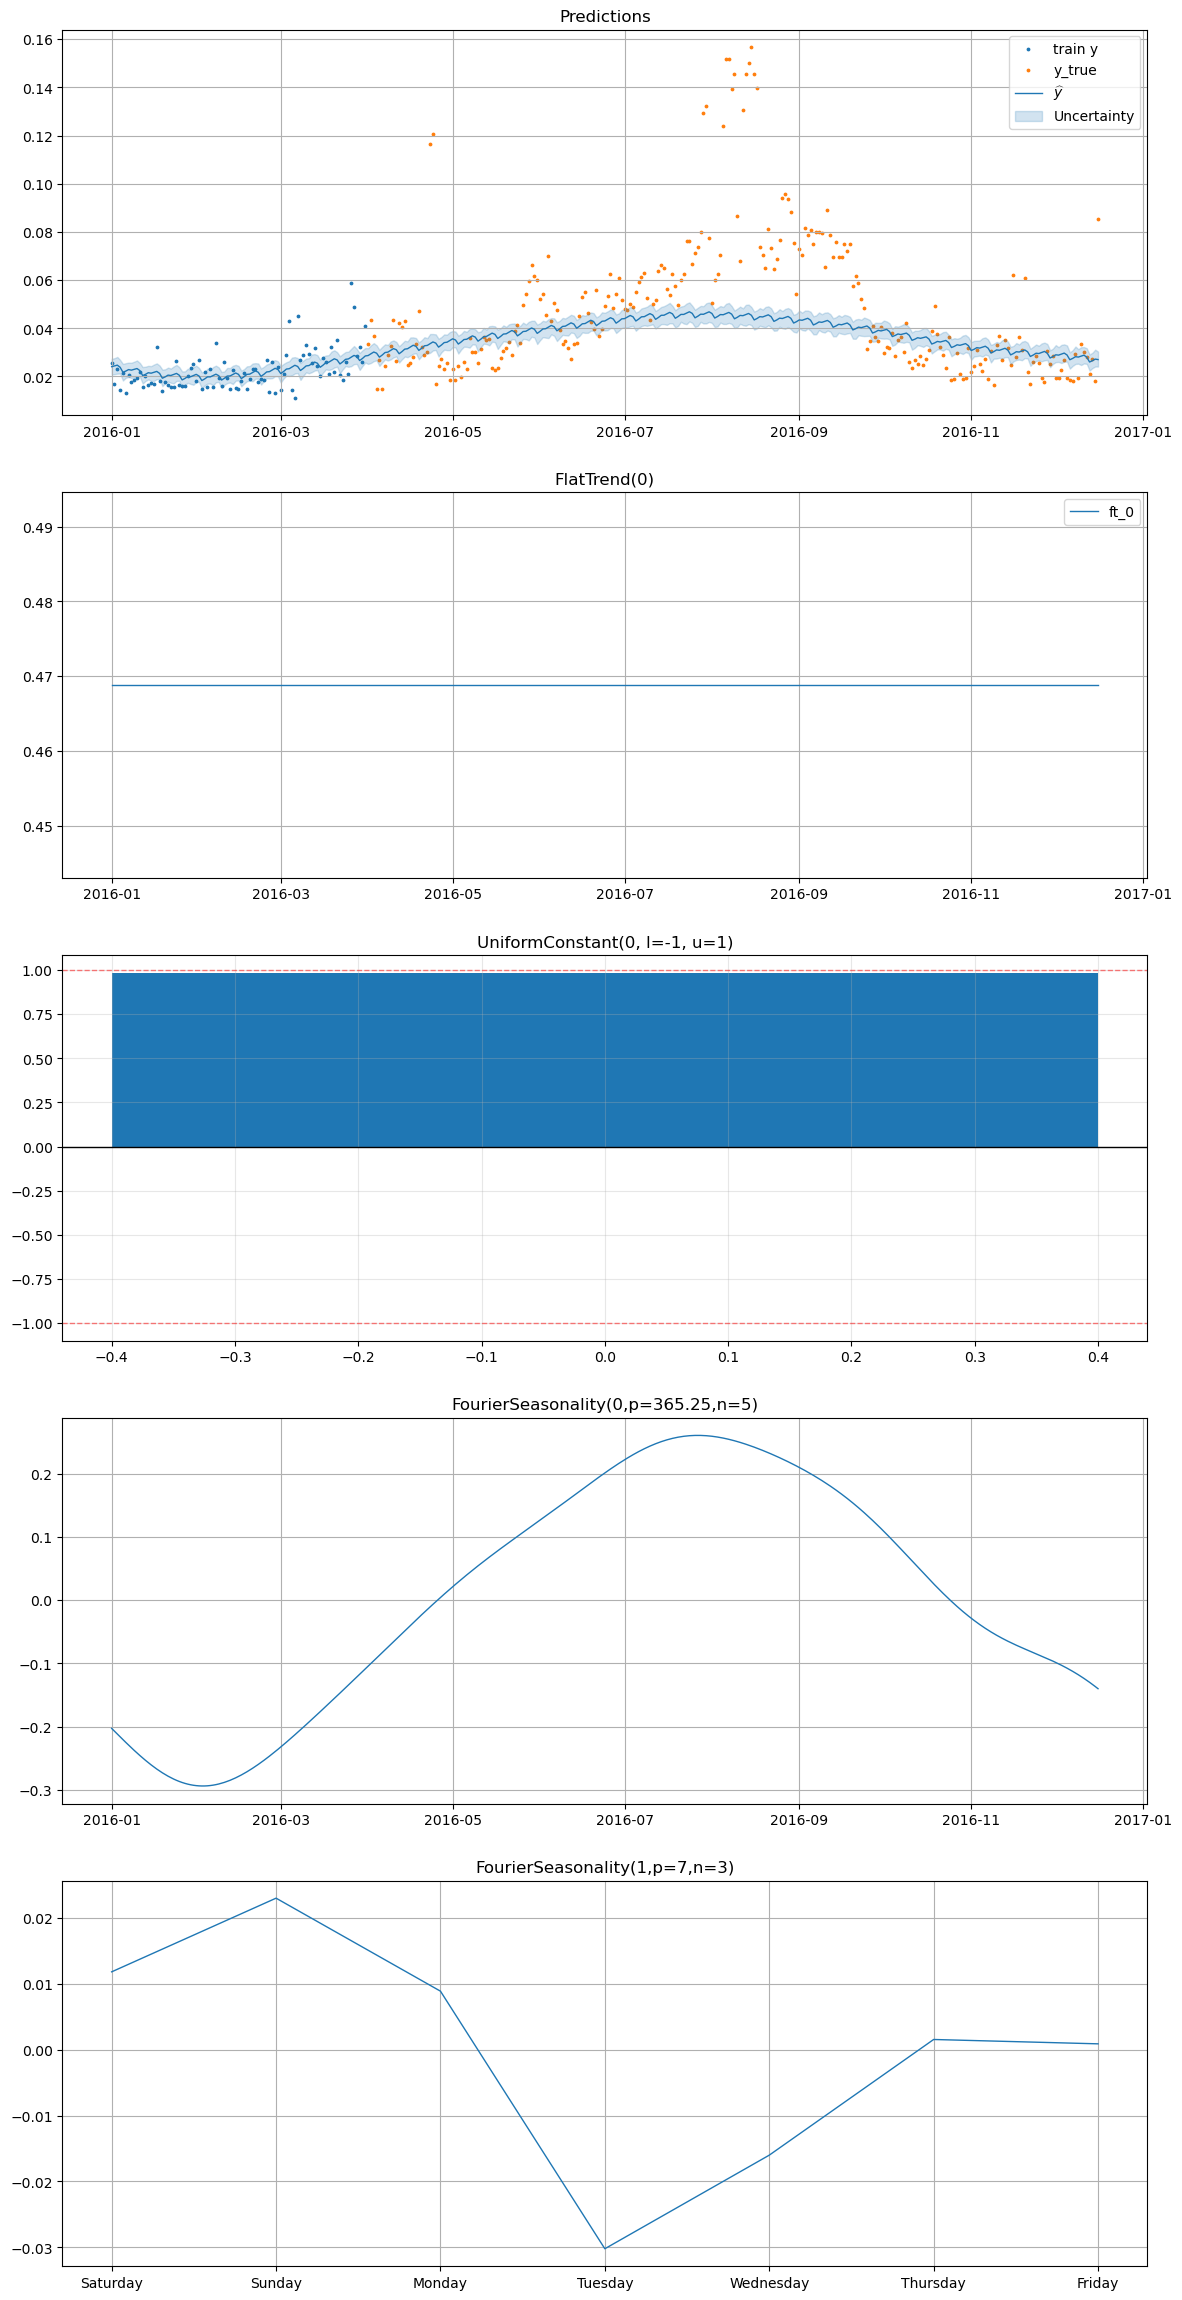

In [25]:
smart_home_model.plot(
    future,
    series="Wine cellar [kW]",
    y_true=smart_home_df[
        (smart_home_df["series"] == "Wine cellar [kW]")
        & (smart_home_df["ds"] >= "2016-04-01")
    ],
)

## 4. Ablation study

We run an ablation study to evaluate the impact of:
- various `beta_sd` values for the seasonality component
- various `intercept_sd` values for the flat trend component
- including vs excluding the temperature data in the energy consumption model
- varying the temperature model's training data size (e.g. using 1 year vs 2 years vs 3 years of temperature data)
- individual vs hierarchical modeling of the energy consumption series, while varying the shrinkage strength for the hierarchical model
- including vs excluding the `UniformConstant` component in the energy consumption model, with analysis of the effect of **negative** transfer learning (i.e. when the temperature model's seasonality patterns do not align well with the energy consumption data)
- using different transfer learning methods (`parametric` vs `prior_from_idata`)
- using the transfer learning regularization term vs not using it in the energy consumption model
- various data scaling methods (`maxabs` vs `minmax`)

These results are obtained by running the `run.py` script in the `case_studies/smart_home` directory, which trains multiple models with different configurations and saves the metrics for each model in a CSV file. We will analyze these results to understand the impact of each of these factors on the performance of our energy consumption forecasting model.

### 4.1 Comparing the results

We will start by comparing the results of the best Vangja model for each time series vs Prophet vs classical time series forecasting methods (e.g. ARIMA, Exponential Smoothing) in terms of the metrics on the test set.

In [27]:
METRICS = ["mse", "rmse", "mae", "mape"]
vangja_df = pd.read_csv("../../../case_studies/smart_home/metrics.csv")
best_vangja_metrics = vangja_df.groupby(["timeseries"], as_index=False)[METRICS].min()
best_vangja_metrics

,timeseries,mse,rmse,mae,mape
0,Boston,10.758126,3.279958,2.563462,0.325475
1,Fridge [kW],0.000159,0.012626,0.009965,0.149766
2,Furnace 1 [kW],0.003007,0.054832,0.042064,0.857102
3,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211
4,Wine cellar [kW],0.000508,0.022540,0.013687,0.247345


#### 4.1.1 Comparing the best Vangja model vs Prophet

We train two Prophet models for each energy consumption series: one with a yearly seasonality component and one without it, to see the impact of including the yearly seasonality component when the data is limited.

In [21]:
smh_train_df = smart_home_df[smart_home_df["ds"] < "2016-04-01"]
smh_test_df = smart_home_df[smart_home_df["ds"] >= "2016-04-01"]
prophet_models: dict[str, TimeSeriesModel] = {}
prophet_forecasts: dict[str, pd.DataFrame] = {}
prophet_metrics: dict[str, pd.DataFrame] = {}

for use_yearly_seasonality in [False, True]:
    seasonalities = FourierSeasonality(
        period=7,
        series_order=3,
        beta_sd=1.5,
        pool_type="individual",
    )
    if use_yearly_seasonality:
        seasonalities += FourierSeasonality(
            period=365.25,
            series_order=5,
            beta_sd=1.5,
            pool_type="individual",
        )
    prophet_model = (
        FlatTrend(intercept_mean=0.5, intercept_sd=0.1, pool_type="individual")
        + seasonalities
    )

    prophet_model.fit(
        smh_train_df, scale_mode="individual", sigma_pool_type="individual"
    )
    y_hat = prophet_model.predict(horizon=365)
    prophet_metrics[str(use_yearly_seasonality)] = metrics(
        smh_test_df, y_hat, pool_type="individual"
    )
    prophet_models[str(use_yearly_seasonality)] = prophet_model
    prophet_forecasts[str(use_yearly_seasonality)] = y_hat

Output()

Output()

In [22]:
prophet_metrics["False"]

,mse,rmse,mae,mape
Fridge [kW],0.000415,0.020369,0.015457,0.207095
Furnace 1 [kW],0.018450,0.135830,0.126426,3.906535
Furnace 2 [kW],0.014101,0.118746,0.108963,1.363224
Wine cellar [kW],0.001572,0.039654,0.027304,0.434458


In [23]:
prophet_metrics["True"]

,mse,rmse,mae,mape
Fridge [kW],0.000918,0.030292,0.025573,0.370468
Furnace 1 [kW],0.840458,0.916765,0.757553,21.094120
Furnace 2 [kW],0.273313,0.522793,0.434639,4.784494
Wine cellar [kW],0.004391,0.066261,0.057956,1.441110


We now calculate the improvement of the best Vangja model over the best Prophet model for each energy consumption series.

In [24]:
prophet_false = prophet_metrics["False"].copy()
prophet_false.index.name = "timeseries"
prophet_false = prophet_false.reset_index()

improvement_false = prophet_false.merge(
    best_vangja_metrics[["timeseries", *METRICS]],
    on="timeseries",
    how="inner",
    suffixes=("_prophet", "_vangja"),
)

for metric in METRICS:
    improvement_false[f"{metric}_improvement_pct"] = (
        (improvement_false[f"{metric}_prophet"] - improvement_false[f"{metric}_vangja"])
        / improvement_false[f"{metric}_prophet"]
        * 100
    )

improvement_false[
    ["timeseries", *[f"{metric}_improvement_pct" for metric in METRICS]]
].round(2)

,timeseries,mse_improvement_pct,rmse_improvement_pct,mae_improvement_pct,mape_improvement_pct
0,Fridge [kW],61.58,38.01,35.53,27.68
1,Furnace 1 [kW],83.70,59.63,66.73,78.06
2,Furnace 2 [kW],76.41,51.43,63.31,73.94
3,Wine cellar [kW],67.69,43.16,49.87,43.07


We observe the plot of one of the Prophet forecasts with and without the yearly seasonality component.

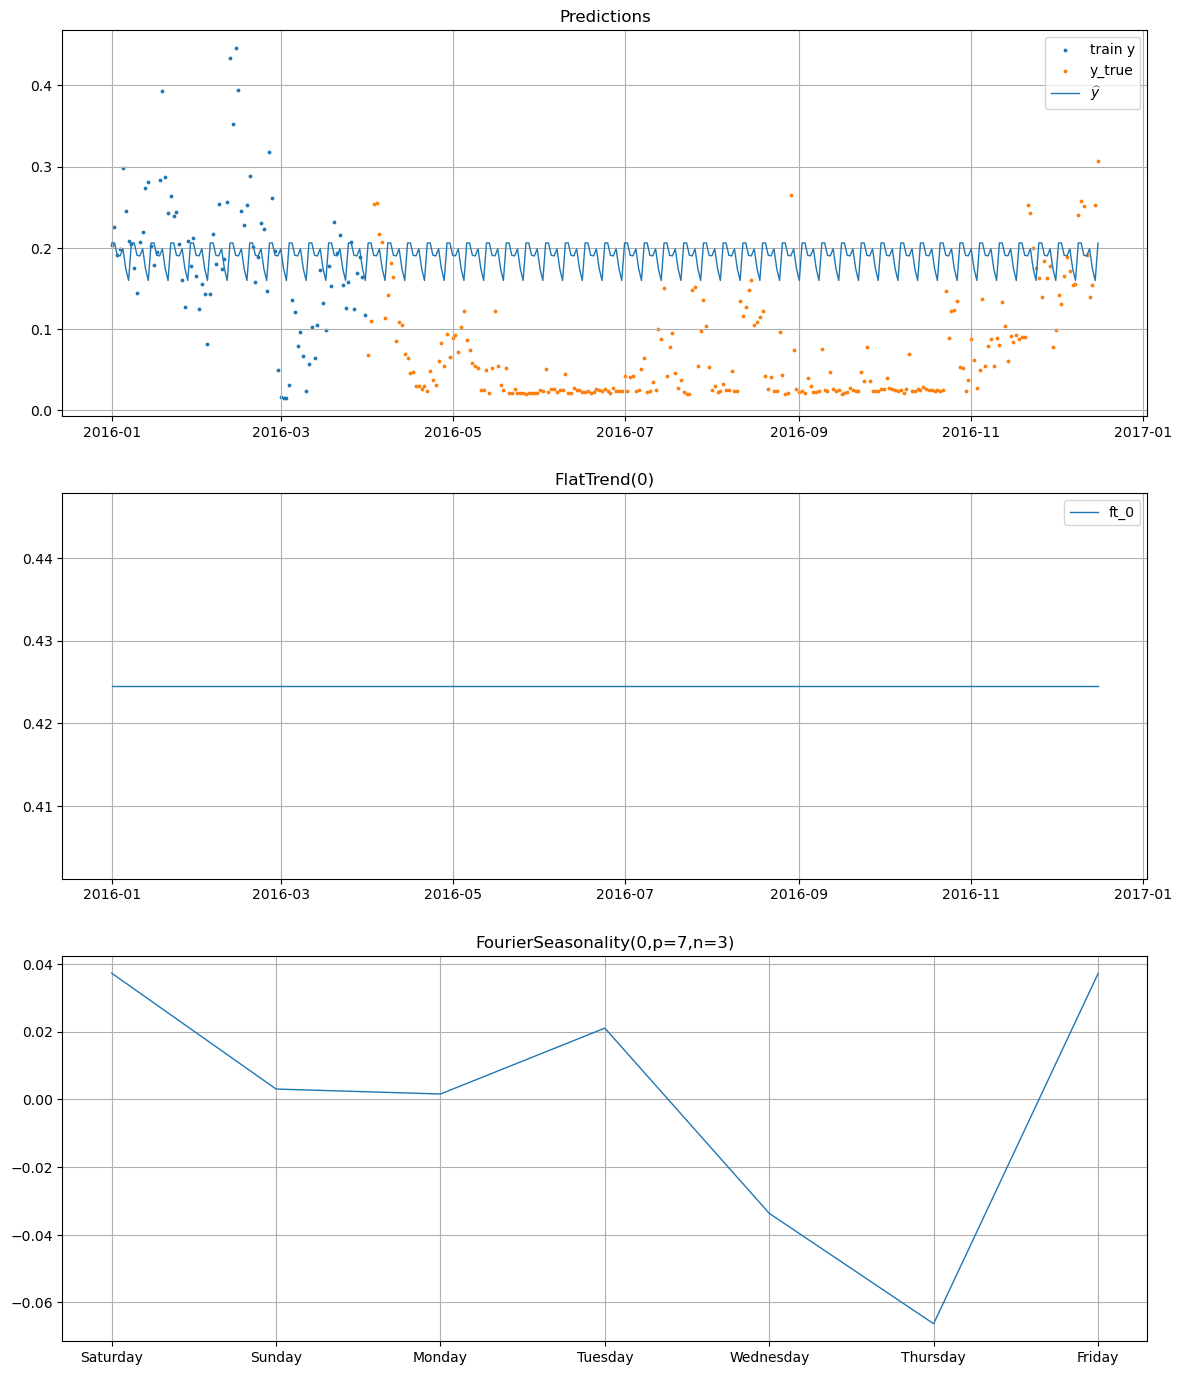

In [25]:
prophet_models["False"].plot(
    prophet_forecasts["False"],
    series="Furnace 1 [kW]",
    y_true=smh_test_df[smh_test_df["series"] == "Furnace 1 [kW]"],
)

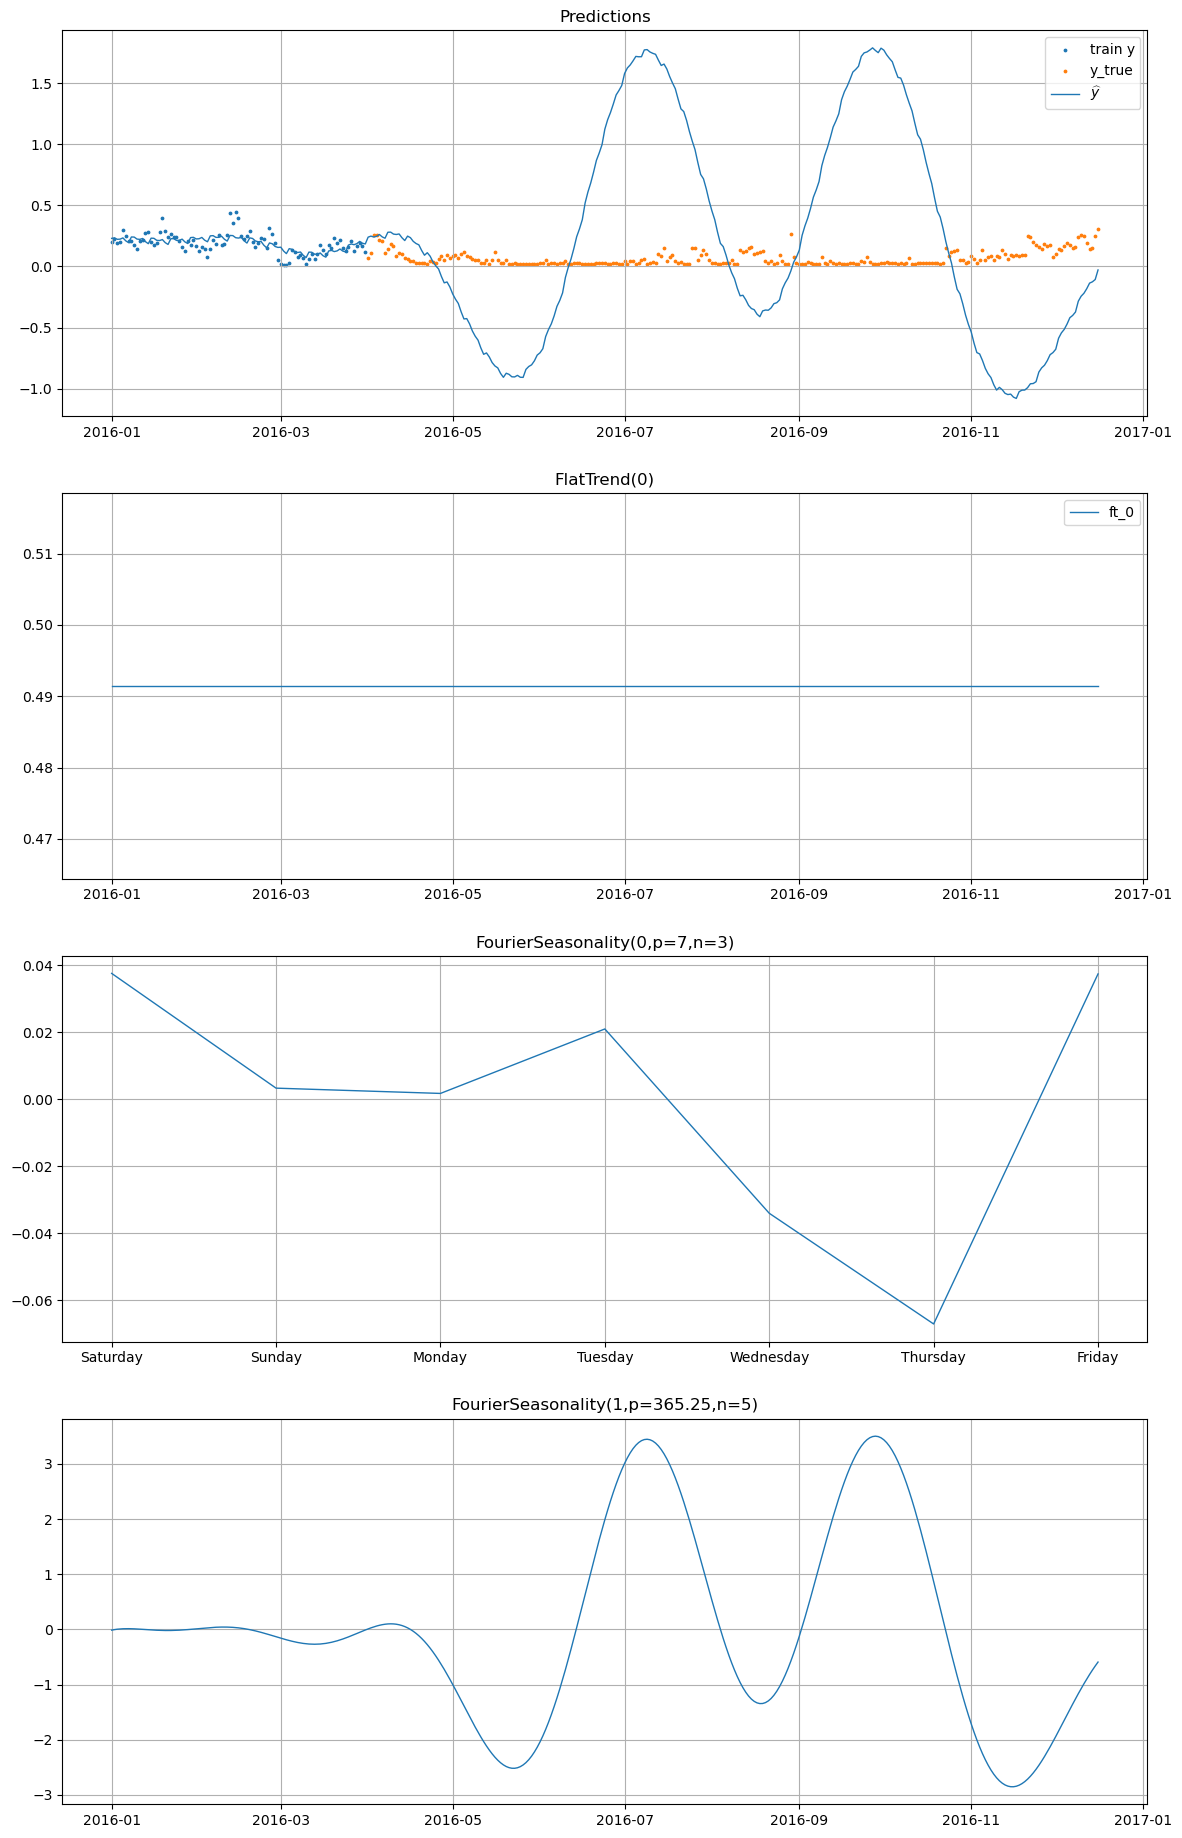

In [26]:
prophet_models["True"].plot(
    prophet_forecasts["True"],
    series="Furnace 1 [kW]",
    y_true=smh_test_df[smh_test_df["series"] == "Furnace 1 [kW]"],
)

#### 4.1.2 Comparing the best Vangja model vs classical time series forecasting methods

We run the following classical time series forecasting methods as *naive* baselines for each energy consumption series:
- Seasonal Naive with seasonality of 7 and 30 (weekly/monthly seasonality)
- Seasonal Naive Mean with seasonality of 7 (weekly seasonality)
- Rolling Mean with window size of 7, 14 and 30 (weekly/bi-weekly/monthly)
- Global Mean

We also run the following ARIMA-based models:
- ARIMA(1,1,1)
- ARIMA(2,1,1)
- SARIMA(1,1,1)(1,0,1,7) (weekly seasonality)
- Auto-ARIMA which selects the best ARIMA model based on AIC

We also run the following Exponential Smoothing models:
- Holt-Winters with additive trend, additive seasonality of 7 (weekly seasonality)
- Holt-Winters with additive trend, multiplicative seasonality of 7 (weekly seasonality)
- Holt-Winters with additive damped trend, additive seasonality of 7 (weekly seasonality)
- Holt-Winters with additive trend, additive seasonality of 30 (monthly seasonality)

We also run two temperature-informed regression models that are meant to serve as simple baseline against our transfer learning approach:
- A linear regression model with the temperature as a feature, along with day of week and month as additional features to capture weekly and monthly seasonality patterns
- A linear regression model with only the temperature as a feature to see how much the temperature alone can explain the variance in the energy consumption data

The results are obtained by running the `run_classical_baselines.py` script in the `case_studies/smart_home` directory, which trains all of these models and saves their metrics in a CSV file. We will analyze these results to compare the performance of our best Vangja model against these classical time series forecasting methods and the temperature-informed regression baselines.

In [33]:
classical_df = pd.read_csv(
    "../../../case_studies/smart_home/results_classical/classical_metrics.csv"
)
best_classical_metrics = classical_df.groupby(["series"], as_index=False)[
    ["rmse", "mae", "mape"]
].min()
best_classical_metrics

,series,rmse,mae,mape
0,Fridge [kW],0.016033,0.011891,0.163297
1,Furnace 1 [kW],0.057297,0.042241,0.926027
2,Furnace 2 [kW],0.067727,0.048607,0.446496
3,Wine cellar [kW],0.032130,0.021512,0.337142


In [35]:
# Compare only metrics available in both tables
common_metrics = [
    m for m in METRICS if m in best_vangja_metrics.columns and m in best_classical_metrics.columns
]

classical_vs_vangja = best_classical_metrics.merge(
    best_vangja_metrics[["timeseries", *common_metrics]],
    left_on="series",
    right_on="timeseries",
    how="inner",
    suffixes=("_classical", "_vangja"),
)

for m in common_metrics:
    classical_vs_vangja[f"{m}_improvement_pct"] = (
        (classical_vs_vangja[f"{m}_classical"] - classical_vs_vangja[f"{m}_vangja"])
        / classical_vs_vangja[f"{m}_classical"]
        * 100
    )

classical_vs_vangja[
    ["series", *[f"{m}_improvement_pct" for m in common_metrics]]
].round(2)

,series,rmse_improvement_pct,mae_improvement_pct,mape_improvement_pct
0,Fridge [kW],21.25,16.20,8.29
1,Furnace 1 [kW],4.30,0.42,7.44
2,Furnace 2 [kW],14.84,17.76,20.44
3,Wine cellar [kW],29.85,36.37,26.63


### 4.2 Ablation study results

#### 4.2.1 Impact of the `beta_sd` value for the seasonality component

We observe that the impact of the `beta_sd` value is neglectable for all of the energy consumption series.

In [47]:
print("--- Average metrics for various beta_sd values ---")
vangja_df.groupby(["beta_sd", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for various beta_sd values ---


,beta_sd,timeseries,mse,rmse,mae,mape
0,0.5,Boston,17.803126,3.972854,3.165578,0.536916
10,1.5,Boston,17.854668,3.978332,3.170189,0.537586
5,1.0,Boston,17.845418,3.977362,3.169462,0.537748
6,1.0,Fridge [kW],0.000912,0.026247,0.023109,0.360039
11,1.5,Fridge [kW],0.000913,0.026256,0.023118,0.360114
1,0.5,Fridge [kW],0.000918,0.026326,0.023193,0.361307
12,1.5,Furnace 1 [kW],0.080906,0.263745,0.245296,7.358590
7,1.0,Furnace 1 [kW],0.080924,0.263771,0.245318,7.358612
2,0.5,Furnace 1 [kW],0.081154,0.264012,0.245599,7.365022
13,1.5,Furnace 2 [kW],0.061299,0.227230,0.210466,2.557709


In [48]:
print("--- Best metrics for various beta_sd values ---")
vangja_df.groupby(["beta_sd", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for various beta_sd values ---


,beta_sd,timeseries,mse,rmse,mae,mape
0,0.5,Boston,10.762218,3.280582,2.564033,0.325475
5,1.0,Boston,10.758537,3.280021,2.563522,0.325475
10,1.5,Boston,10.758126,3.279958,2.563462,0.325476
1,0.5,Fridge [kW],0.000159,0.012628,0.009965,0.149766
6,1.0,Fridge [kW],0.000159,0.012626,0.009977,0.150104
11,1.5,Fridge [kW],0.000159,0.012626,0.009989,0.150136
12,1.5,Furnace 1 [kW],0.003019,0.054948,0.042932,0.857102
2,0.5,Furnace 1 [kW],0.003007,0.054832,0.042635,0.859838
7,1.0,Furnace 1 [kW],0.003040,0.055135,0.042064,0.865945
3,0.5,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211


#### 4.2.2 Impact of the `intercept_sd` value for the flat trend component

The `intercept_sd` value has a more significant impact on the performance of the model. We observe that a smaller `intercept_sd` value (e.g. 0.1) leads to better performance for most of the energy consumption series. However, the best result for the `Furnace 2 [kW]` series gets significantly worse with an `intercept_sd` value of 0.1, which suggests that a slightly larger `intercept_sd` value (e.g. 0.5) might be better for this series to allow for more flexibility in the flat trend component. 

In [49]:
print("--- Average metrics for various intercept_sd values ---")
vangja_df.groupby(["intercept_sd", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for various intercept_sd values ---


,intercept_sd,timeseries,mse,rmse,mae,mape
0,0.1,Boston,17.673191,3.962663,3.156712,0.535361
5,0.5,Boston,17.907684,3.982412,3.173527,0.537409
10,1.0,Boston,17.922337,3.983474,3.174989,0.539480
1,0.1,Fridge [kW],0.000884,0.025910,0.022795,0.355824
6,0.5,Fridge [kW],0.000925,0.026393,0.023242,0.361680
11,1.0,Fridge [kW],0.000934,0.026528,0.023383,0.363955
7,0.5,Furnace 1 [kW],0.081630,0.264459,0.245747,7.352693
2,0.1,Furnace 1 [kW],0.079235,0.261783,0.243840,7.353796
12,1.0,Furnace 1 [kW],0.082119,0.265286,0.246626,7.375736
3,0.1,Furnace 2 [kW],0.059600,0.224012,0.207669,2.531630


In [50]:
print("--- Best metrics for various intercept_sd values ---")
vangja_df.groupby(["intercept_sd", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for various intercept_sd values ---


,intercept_sd,timeseries,mse,rmse,mae,mape
10,1.0,Boston,10.759939,3.280235,2.563776,0.325475
5,0.5,Boston,10.758126,3.279958,2.563462,0.325495
0,0.1,Boston,10.842214,3.292752,2.569638,0.326191
11,1.0,Fridge [kW],0.000159,0.012626,0.010103,0.149766
1,0.1,Fridge [kW],0.000162,0.012718,0.009965,0.150098
6,0.5,Fridge [kW],0.000160,0.012638,0.010208,0.150594
12,1.0,Furnace 1 [kW],0.003007,0.054832,0.042932,0.857102
7,0.5,Furnace 1 [kW],0.003028,0.055031,0.042064,0.859838
2,0.1,Furnace 1 [kW],0.003529,0.059404,0.048588,1.163437
8,0.5,Furnace 2 [kW],0.003343,0.057815,0.040267,0.355211


#### 4.2.3 Impact of including vs excluding the temperature data in the energy consumption model

We observe a much higher impact of including vs excluding the temperature data in the energy consumption model compared to the other factors we analyzed in this ablation study. Interestingly enough, on average, excluding the temperature data from the energy consumption model leads to a significant increase in the MAPE metric for all of the energy consumption series. However, the best model that uses the temperature data always outperforms the best model that does not use the temperature data.

In [44]:
print("--- Average metrics for models with vs without temperature data ---")
vangja_df.groupby(["use_temp_df", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for models with vs without temperature data ---


,use_temp_df,timeseries,mse,rmse,mae,mape
5,without_temp_df,Boston,17.213267,3.921812,3.132792,0.516706
0,with_temp_df,Boston,17.958631,3.987057,3.175533,0.541559
6,without_temp_df,Fridge [kW],0.000723,0.023769,0.020171,0.305506
1,with_temp_df,Fridge [kW],0.000953,0.026778,0.023734,0.371483
7,without_temp_df,Furnace 1 [kW],0.058709,0.212255,0.195777,5.841780
2,with_temp_df,Furnace 1 [kW],0.085452,0.274160,0.255330,7.664534
8,without_temp_df,Furnace 2 [kW],0.044145,0.183439,0.167219,2.019838
3,with_temp_df,Furnace 2 [kW],0.064863,0.236194,0.219307,2.667202
9,without_temp_df,Wine cellar [kW],0.000873,0.029046,0.019288,0.370509
4,with_temp_df,Wine cellar [kW],0.000751,0.027176,0.018127,0.372991


In [45]:
print("--- Best metrics for models with vs without temperature data ---")
vangja_df.groupby(["use_temp_df", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for models with vs without temperature data ---


,use_temp_df,timeseries,mse,rmse,mae,mape
0,with_temp_df,Boston,10.758126,3.279958,2.563462,0.325475
5,without_temp_df,Boston,10.802376,3.286697,2.567327,0.413517
1,with_temp_df,Fridge [kW],0.000159,0.012626,0.009965,0.149766
6,without_temp_df,Fridge [kW],0.000169,0.013016,0.009989,0.150098
2,with_temp_df,Furnace 1 [kW],0.003046,0.055193,0.042064,0.857102
7,without_temp_df,Furnace 1 [kW],0.003007,0.054832,0.042950,0.946538
3,with_temp_df,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211
8,without_temp_df,Furnace 2 [kW],0.003383,0.058161,0.040766,0.360805
4,with_temp_df,Wine cellar [kW],0.000513,0.022644,0.013687,0.247345
9,without_temp_df,Wine cellar [kW],0.000508,0.022540,0.014040,0.250215


#### 4.2.4 Impact of varying the temperature model's training data size (e.g. using 1 year vs 2 years vs 3 years of temperature data)

The high impact of varying the temperature model's training data size is evident. On average, it would seem that using less temperature data is preferred. However, when looking at the best models, such a conclusion cannot be drawn.

In [51]:
print("--- Average metrics for based on temperature training data size ---")
vangja_df.groupby(["start_date", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for based on temperature training data size ---


,start_date,timeseries,mse,rmse,mae,mape
0,2013-01-01,Boston,15.857805,3.757987,2.992790,0.492004
5,2014-01-01,Boston,18.329866,4.026787,3.224379,0.547438
10,2015-01-01,Boston,19.315540,4.143775,3.288059,0.572808
11,2015-01-01,Fridge [kW],0.000834,0.025230,0.022054,0.342261
1,2013-01-01,Fridge [kW],0.000929,0.026499,0.023366,0.364544
6,2014-01-01,Fridge [kW],0.000980,0.027101,0.024001,0.374655
12,2015-01-01,Furnace 1 [kW],0.077527,0.258142,0.239463,7.165934
2,2013-01-01,Furnace 1 [kW],0.081983,0.265724,0.247384,7.437097
7,2014-01-01,Furnace 1 [kW],0.083473,0.267663,0.249366,7.479193
13,2015-01-01,Furnace 2 [kW],0.058053,0.221236,0.204224,2.478657


In [52]:
print("--- Best metrics for based on temperature training data size ---")
vangja_df.groupby(["start_date", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for based on temperature training data size ---


,start_date,timeseries,mse,rmse,mae,mape
10,2015-01-01,Boston,12.021670,3.467228,2.658879,0.325475
5,2014-01-01,Boston,11.246847,3.353632,2.597529,0.381618
0,2013-01-01,Boston,10.758126,3.279958,2.563462,0.399876
11,2015-01-01,Fridge [kW],0.000162,0.012718,0.009965,0.149766
1,2013-01-01,Fridge [kW],0.000159,0.012626,0.010136,0.150225
6,2014-01-01,Fridge [kW],0.000167,0.012931,0.010142,0.151104
2,2013-01-01,Furnace 1 [kW],0.003007,0.054832,0.042064,0.857102
7,2014-01-01,Furnace 1 [kW],0.003089,0.055583,0.042635,0.859838
12,2015-01-01,Furnace 1 [kW],0.003437,0.058626,0.046048,0.966525
3,2013-01-01,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211


#### 4.2.5 Impact of individual vs hierarchical modeling of the energy consumption series, while varying the shrinkage strength for the hierarchical model

Hierarchical modeling, on average, seems to make the performance worse for most of the energy consumption series. The reason behind this is that hierarchical modeling introduces a new hyperparameter, the shrinkage strength, which can be difficult to tune properly. If the shrinkage strength is too high, it can lead to underfitting and worse performance. If it is too low, it can lead to overfitting and also worse performance. Therefore, it is crucial to carefully tune the shrinkage strength when using hierarchical modeling to ensure that it improves the performance of the model rather than making it worse.

That hierarchical modeling makes sense for this case study is evident when we look at the best models. For every energy consumption series, the best model is a hierarchical model. This suggests that hierarchical modeling can be beneficial for improving the performance of the energy consumption forecasting models, but it requires careful tuning of the shrinkage strength to achieve the best results.

In [54]:
print("--- Average metrics for individual vs hierarchical modeling ---")
vangja_df.groupby(["hierarchical", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for individual vs hierarchical modeling ---


,hierarchical,timeseries,mse,rmse,mae,mape
0,individual,Boston,17.213267,3.921812,3.132792,0.516706
5,partial,Boston,17.958631,3.987057,3.175533,0.541559
1,individual,Fridge [kW],0.000723,0.023769,0.020171,0.305506
6,partial,Fridge [kW],0.000953,0.026778,0.023734,0.371483
2,individual,Furnace 1 [kW],0.058709,0.212255,0.195777,5.841780
7,partial,Furnace 1 [kW],0.085452,0.274160,0.255330,7.664534
3,individual,Furnace 2 [kW],0.044145,0.183439,0.167219,2.019838
8,partial,Furnace 2 [kW],0.064863,0.236194,0.219307,2.667202
4,individual,Wine cellar [kW],0.000873,0.029046,0.019288,0.370509
9,partial,Wine cellar [kW],0.000751,0.027176,0.018127,0.372991


In [56]:
print("--- Best metrics for individual vs hierarchical modeling ---")
vangja_df.groupby(["hierarchical", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for individual vs hierarchical modeling ---


,hierarchical,timeseries,mse,rmse,mae,mape
5,partial,Boston,10.758126,3.279958,2.563462,0.325475
0,individual,Boston,10.802376,3.286697,2.567327,0.413517
6,partial,Fridge [kW],0.000159,0.012626,0.009965,0.149766
1,individual,Fridge [kW],0.000169,0.013016,0.009989,0.150098
7,partial,Furnace 1 [kW],0.003046,0.055193,0.042064,0.857102
2,individual,Furnace 1 [kW],0.003007,0.054832,0.042950,0.946538
8,partial,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211
3,individual,Furnace 2 [kW],0.003383,0.058161,0.040766,0.360805
9,partial,Wine cellar [kW],0.000513,0.022644,0.013687,0.247345
4,individual,Wine cellar [kW],0.000508,0.022540,0.014040,0.250215


We observe the high impact that the shrinkage strength has on the performance of the hierarchical models, for both the average and the best models.

In [57]:
print("--- Average metrics for various shrinkage strengths ---")
vangja_df[vangja_df["hierarchical"] == "partial"].groupby(["shrinkage_strength", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for various shrinkage strengths ---


,shrinkage_strength,timeseries,mse,rmse,mae,mape
0,1,Boston,17.867709,3.960893,3.146280,0.535130
5,10,Boston,17.733691,3.965068,3.153208,0.540390
10,100,Boston,18.022696,3.999284,3.186527,0.541352
20,10000,Boston,18.084883,4.005078,3.195785,0.545374
15,1000,Boston,18.084175,4.004963,3.195864,0.545549
1,1,Fridge [kW],0.000722,0.023251,0.019765,0.302808
6,10,Fridge [kW],0.000738,0.023285,0.020065,0.310001
11,100,Fridge [kW],0.001087,0.028931,0.026088,0.411734
16,1000,Fridge [kW],0.001106,0.029181,0.026344,0.415907
21,10000,Fridge [kW],0.001111,0.029242,0.026407,0.416964


In [58]:
print("--- Best metrics for various shrinkage strengths ---")
vangja_df[vangja_df["hierarchical"] == "partial"].groupby(["shrinkage_strength", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for various shrinkage strengths ---


,shrinkage_strength,timeseries,mse,rmse,mae,mape
10,100,Boston,10.877772,3.298147,2.574977,0.325475
5,10,Boston,10.849944,3.293925,2.570414,0.325480
20,10000,Boston,10.758126,3.279958,2.563462,0.325495
15,1000,Boston,10.758144,3.279961,2.563465,0.325495
0,1,Boston,10.823834,3.289960,2.566520,0.325805
1,1,Fridge [kW],0.000163,0.012781,0.009977,0.149766
6,10,Fridge [kW],0.000161,0.012677,0.009965,0.150225
21,10000,Fridge [kW],0.000159,0.012626,0.010344,0.164174
16,1000,Fridge [kW],0.000159,0.012626,0.010344,0.164174
11,100,Fridge [kW],0.000195,0.013947,0.011882,0.180887


#### 4.2.6 Impact of including vs excluding the `UniformConstant` component in the energy consumption model, with analysis of the effect of **negative** transfer learning

We observe a significant impact of including vs excluding the `UniformConstant` component in the energy consumption model. On average, including the `UniformConstant` component leads to better performance for most of the energy consumption series. However, when looking at the best models, we can see that for some energy consumption series, excluding the `UniformConstant` component leads to better performance.

In [59]:
print("--- Average metrics for including vs excluding the UniformConstant ---")
vangja_df.groupby(["uniform_constant", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for including vs excluding the UniformConstant ---


,uniform_constant,timeseries,mse,rmse,mae,mape
0,False,Boston,12.729899,3.521365,2.752423,0.460010
5,True,Boston,22.938908,4.431001,3.584396,0.614824
6,True,Fridge [kW],0.000623,0.022008,0.018475,0.279778
1,False,Fridge [kW],0.001205,0.030545,0.027805,0.441195
7,True,Furnace 1 [kW],0.052297,0.201116,0.186282,5.548053
2,False,Furnace 1 [kW],0.109692,0.326569,0.304527,9.173430
8,True,Furnace 2 [kW],0.038834,0.171192,0.156156,1.883276
3,False,Furnace 2 [kW],0.083987,0.283611,0.265095,3.235340
9,True,Wine cellar [kW],0.000865,0.029026,0.019112,0.365596
4,False,Wine cellar [kW],0.000678,0.025949,0.017529,0.379558


In [60]:
print("--- Best metrics for including vs excluding the UniformConstant ---")
vangja_df.groupby(["uniform_constant", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for including vs excluding the UniformConstant ---


,uniform_constant,timeseries,mse,rmse,mae,mape
0,False,Boston,10.758126,3.279958,2.563462,0.325475
5,True,Boston,10.823834,3.289960,2.566520,0.411647
6,True,Fridge [kW],0.000162,0.012718,0.009965,0.149766
1,False,Fridge [kW],0.000159,0.012626,0.010344,0.164174
7,True,Furnace 1 [kW],0.003007,0.054832,0.042064,0.857102
2,False,Furnace 1 [kW],0.050341,0.224367,0.206284,6.361467
8,True,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211
3,False,Furnace 2 [kW],0.032464,0.180178,0.163948,2.053506
4,False,Wine cellar [kW],0.000508,0.022540,0.013687,0.247345
9,True,Wine cellar [kW],0.000520,0.022802,0.015768,0.308768


Negative transfer learning can occur when the seasonality patterns learned from the temperature model do not align well with the seasonality patterns in the energy consumption data. In such cases, including the `UniformConstant` component in the energy consumption model can help mitigate the negative impact of transfer learning by multiplying the transferred seasonality component by a constant value that can be learned from the data.

Specifically, the series `Furnace 1 [kW]` and `Furnace 2 [kW]` have an inverse relationship with the temperature data, meaning that their energy consumption tends to be higher when the temperature is lower. In such cases, including the `UniformConstant` component can drammatically help the model learn to adjust the transferred seasonality component in a way that better aligns with the observed patterns in the energy consumption data, leading to improved performance.

#### 4.2.7 Impact of using different transfer learning methods (`parametric` vs `prior_from_idata`)

On average, using the `parametric` transfer learning method leads to better performance compared to using the `prior_from_idata` transfer learning method for most of the energy consumption series. However, when looking at the best models, we can make the opposite conclusion, that using the `prior_from_idata` transfer learning method leads to better performance compared to using the `parametric` transfer learning method for most of the energy consumption series. This suggests that the choice of transfer learning method can have a significant impact on the performance of the energy consumption forecasting models, and it may be beneficial to try both methods and compare their results to determine which one works better for a specific case.

In [64]:
print("--- Average metrics for parametric vs prior_from_idata transfer learning ---")
vangja_df.groupby(["tune_method", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for parametric vs prior_from_idata transfer learning ---


,tune_method,timeseries,mse,rmse,mae,mape
5,prior_from_idata,Boston,12.601696,3.500643,2.733069,0.465555
0,parametric,Boston,23.067111,4.451723,3.603750,0.609278
1,parametric,Fridge [kW],0.000873,0.025626,0.022388,0.347074
6,prior_from_idata,Fridge [kW],0.000956,0.026927,0.023892,0.373899
2,parametric,Furnace 1 [kW],0.076100,0.255244,0.237737,7.141876
7,prior_from_idata,Furnace 1 [kW],0.085889,0.272441,0.253072,7.579607
3,parametric,Furnace 2 [kW],0.057061,0.217683,0.201674,2.457042
8,prior_from_idata,Furnace 2 [kW],0.065760,0.237120,0.219577,2.661575
9,prior_from_idata,Wine cellar [kW],0.000716,0.026562,0.017740,0.370703
4,parametric,Wine cellar [kW],0.000827,0.028413,0.018901,0.374450


In [65]:
print("--- Best metrics for parametric vs prior_from_idata transfer learning ---")
vangja_df.groupby(["tune_method", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for parametric vs prior_from_idata transfer learning ---


,tune_method,timeseries,mse,rmse,mae,mape
0,parametric,Boston,10.758126,3.279958,2.563462,0.325475
5,prior_from_idata,Boston,10.802376,3.286697,2.566520,0.410362
6,prior_from_idata,Fridge [kW],0.000162,0.012718,0.009965,0.149766
1,parametric,Fridge [kW],0.000159,0.012626,0.009967,0.150248
7,prior_from_idata,Furnace 1 [kW],0.003019,0.054948,0.042635,0.857102
2,parametric,Furnace 1 [kW],0.003007,0.054832,0.042064,0.876981
8,prior_from_idata,Furnace 2 [kW],0.003327,0.057678,0.039975,0.355211
3,parametric,Furnace 2 [kW],0.003343,0.057815,0.040298,0.356239
4,parametric,Wine cellar [kW],0.000508,0.022540,0.013687,0.247345
9,prior_from_idata,Wine cellar [kW],0.000517,0.022745,0.014040,0.250216


#### 4.2.8 Impact of using the transfer learning regularization term vs not using it in the energy consumption model

On average, using the transfer learning regularization term leads to better performance. However, this is not the case for the best models. We observe that, for `Furnace 1 [kW]` and `Furnace 2 [kW]`, not using the transfer learning regularization term leads to better performance compared to using it. This makes sense because these two series have an inverse relationship with the temperature data, which means that the seasonality patterns learned from the temperature model might not align well with the seasonality patterns in these energy consumption series. In such cases, using the transfer learning regularization term can actually hurt the performance of the model by forcing it to align the seasonality patterns with the temperature data, which might not be appropriate for these series. Therefore, it is important to carefully consider whether to use the transfer learning regularization term based on the specific characteristics of the data and the relationship between the source and target domains.

In [69]:
print("--- Average metrics for using vs not using transfer learning regularization ---")
vangja_df.groupby(["tune_loss_factor", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for using vs not using transfer learning regularization ---


,tune_loss_factor,timeseries,mse,rmse,mae,mape
0,0,Boston,11.669646,3.414973,2.651346,0.455649
5,1,Boston,23.999162,4.537393,3.685473,0.619185
6,1,Fridge [kW],0.000872,0.025731,0.022474,0.348145
1,0,Fridge [kW],0.000957,0.026822,0.023806,0.372828
7,1,Furnace 1 [kW],0.076939,0.259431,0.242010,7.289547
2,0,Furnace 1 [kW],0.085050,0.268254,0.248798,7.431936
8,1,Furnace 2 [kW],0.057388,0.220050,0.204371,2.496924
3,0,Furnace 2 [kW],0.065432,0.234753,0.216879,2.621693
4,0,Wine cellar [kW],0.000687,0.026106,0.017419,0.368798
9,1,Wine cellar [kW],0.000857,0.028869,0.019223,0.376356


In [70]:
print("--- Average metrics for using vs not using transfer learning regularization ---")
vangja_df.groupby(["tune_loss_factor", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Average metrics for using vs not using transfer learning regularization ---


,tune_loss_factor,timeseries,mse,rmse,mae,mape
5,1,Boston,10.758126,3.279958,2.563462,0.325475
0,0,Boston,10.823834,3.289960,2.566520,0.410124
6,1,Fridge [kW],0.000159,0.012626,0.009977,0.149766
1,0,Fridge [kW],0.000165,0.012845,0.009965,0.150098
2,0,Furnace 1 [kW],0.003007,0.054832,0.042064,0.857102
7,1,Furnace 1 [kW],0.003191,0.056492,0.044730,0.891352
3,0,Furnace 2 [kW],0.003343,0.057815,0.040267,0.355211
8,1,Furnace 2 [kW],0.003327,0.057678,0.039975,0.356386
9,1,Wine cellar [kW],0.000508,0.022540,0.013687,0.247345
4,0,Wine cellar [kW],0.000513,0.022644,0.015768,0.308824


#### 4.2.9 Impact of various data scaling methods (`maxabs` vs `minmax`)

Scaling has a significant impact on the performance of the energy consumption forecasting models. On both the average and best model statistics, using `minmax` scaling leads to better performance compared to using `maxabs` scaling for most of the energy consumption series.

In [71]:
print("--- Average metrics for maxabs vs minmax scaling ---")
vangja_df.groupby(["scaler", "timeseries"], as_index=False)[
    METRICS
].mean().sort_values(["timeseries", "mape"])

--- Average metrics for maxabs vs minmax scaling ---


,scaler,timeseries,mse,rmse,mae,mape
5,minmax,Boston,17.721495,3.964755,3.162148,0.532884
0,maxabs,Boston,17.947312,3.987611,3.174671,0.541950
6,minmax,Fridge [kW],0.000229,0.015054,0.012466,0.200348
1,maxabs,Fridge [kW],0.001600,0.037499,0.033814,0.520625
7,minmax,Furnace 1 [kW],0.058648,0.230786,0.215139,6.489121
2,maxabs,Furnace 1 [kW],0.103341,0.296900,0.275670,8.232362
8,minmax,Furnace 2 [kW],0.040660,0.192812,0.179134,2.194509
3,maxabs,Furnace 2 [kW],0.082161,0.261991,0.242117,2.924107
9,minmax,Wine cellar [kW],0.000867,0.029310,0.018447,0.324178
4,maxabs,Wine cellar [kW],0.000677,0.025665,0.018194,0.420976


In [72]:
print("--- Best metrics for maxabs vs minmax scaling ---")
vangja_df.groupby(["scaler", "timeseries"], as_index=False)[
    METRICS
].min().sort_values(["timeseries", "mape"])

--- Best metrics for maxabs vs minmax scaling ---


,scaler,timeseries,mse,rmse,mae,mape
0,maxabs,Boston,10.802376,3.286697,2.567443,0.325475
5,minmax,Boston,10.758126,3.279958,2.563462,0.399876
6,minmax,Fridge [kW],0.000159,0.012626,0.009965,0.149766
1,maxabs,Fridge [kW],0.000215,0.014666,0.010849,0.154361
7,minmax,Furnace 1 [kW],0.003007,0.054832,0.042064,0.857102
2,maxabs,Furnace 1 [kW],0.003529,0.059404,0.048588,1.158319
8,minmax,Furnace 2 [kW],0.003327,0.057678,0.040267,0.355211
3,maxabs,Furnace 2 [kW],0.003343,0.057815,0.039975,0.356386
4,maxabs,Wine cellar [kW],0.000508,0.022540,0.013687,0.247345
9,minmax,Wine cellar [kW],0.000748,0.027355,0.017160,0.304004
